In [2]:
library(Seurat)
library(data.table)
library(ggplot2)
library(ggpubr)
# library(ComplexHeatmap)
library(RColorBrewer)
library(circlize) # For colorRamp2
library(dplyr)
library(tidyr)
library(ggplot2)


In [3]:
# scdata=readRDS("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step8.scdata_node_w_scores_pseudotime2.rds")
# scdata@meta.data[1:3,]
scdata=readRDS("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step8.scdata_node_w_scores_pseudotime.rds")
scdata@meta.data[1:3,]

,sampleID,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,S.Score,G2M.Score,Phase,old.ident,mouse,⋯,MetGroup,scFitness,scPlasticity,scMetRate,Root_to_tip_distance,CytoTRACE2_Score,CytoTRACE2_Potency,CytoTRACE2_Relative,pseudotime,transition
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
C4007_LLT-1_AAACCCAAGGATTTGA-1,C4007_LLT-1,11995,4489,0.9670696,14.39767,-0.3777723,-0.34343502,G1,LLT-1,4007,⋯,MetGroup1:Primary-tropic,Others,Others,Others,Others,0.114720450450392,Differentiated,0.114848463637216,Others,NA
C4007_LLT-1_AAACCCACACAACGAG-1,C4007_LLT-1,22160,6178,0.3925993,19.72473,-0.1619709,-0.27014986,G1,LLT-1,4007,⋯,MetGroup1:Primary-tropic,0.140631295874457,0.512830249177513,0.00618598807275177,23.05455,0.10132772191846,Differentiated,0.101394697663774,0.42435199895567,ENT
C4007_LLT-1_AAACCCACAGGTCCCA-1,C4007_LLT-1,10826,4438,0.8220950,12.33142,0.3392319,-0.04680737,S,LLT-1,4007,⋯,MetGroup1:Primary-tropic,Others,Others,Others,Others,0.221428917730434,Unipotent,0.22204325540406,Others,ENT


In [3]:
colnames(scdata@meta.data)

[1] "sampleID"              "nCount_RNA"            "nFeature_RNA"         
 [4] "percent.mt"            "percent.ribo"          "S.Score"              
 [7] "G2M.Score"             "Phase"                 "old.ident"            
[10] "mouse"                 "batch"                 "nCount_SCT"           
[13] "nFeature_SCT"          "SCT_snn_res.0.3"       "seurat_clusters"      
[16] "pANN"                  "sampleType"            "unintegrated_clusters"
[19] "harmony_cluster"       "sampleIDnew"           "organ"                
[22] "target"                "inclone"               "clone"                
[25] "umapharmony_1"         "umapharmony_2"         "numMut"               
[28] "mouse_clone"           "MetStatus"             "MetGroup"             
[31] "scFitness"             "scPlasticity"          "scMetRate"            
[34] "Root_to_tip_distance"  "CytoTRACE2_Score"      "CytoTRACE2_Potency"   
[37] "CytoTRACE2_Relative"   "pseudotime"            "transition"

In [5]:
scdata@meta.data[1:3,20:ncol(scdata@meta.data)]

,sampleIDnew,organ,target,inclone,clone,umapharmony_1,umapharmony_2,numMut,mouse_clone,MetStatus,MetGroup,scFitness,scPlasticity,scMetRate,Root_to_tip_distance,CytoTRACE2_Score,CytoTRACE2_Potency,CytoTRACE2_Relative,pseudotime,transition
,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
C4007_LLT-1_AAACCCAAGGATTTGA-1,C4007_PT,PT,Y,Y,22,-4.92653453,2.6064245,Others,4007_22,Non-metastatic,MetGroup1:Primary-tropic,Others,Others,Others,Others,0.114720450450392,Differentiated,0.114848463637216,Others,NA
C4007_LLT-1_AAACCCACACAACGAG-1,C4007_PT,PT,Y,Y,7,0.02939433,0.9881048,27,4007_7,Non-metastatic,MetGroup1:Primary-tropic,0.140631295874457,0.512830249177513,0.00618598807275177,23.05455,0.10132772191846,Differentiated,0.101394697663774,0.42435199895567,ENT
C4007_LLT-1_AAACCCACAGGTCCCA-1,C4007_PT,PT,Y,Y,4,-2.21210611,1.1767958,Others,4007_4,Non-metastatic,MetGroup1:Primary-tropic,Others,Others,Others,Others,0.221428917730434,Unipotent,0.22204325540406,Others,ENT


In [6]:
table(scdata@meta.data$harmony_cluster)


    0     1     2     3     4     5     6     7     8 
49098 34751 15923 15728 12201 11022  6392  5548  3804 

In [64]:
nrow(scdata@meta.data[scdata@meta.data$pseudotime != "Others",])

[1] 27946

In [65]:
nrow(scdata@meta.data[scdata@meta.data$pseudotimeByClone != "Others",])

[1] 28701

# 1. phylovelo pseudotime

In [9]:
###################################################
## 1. add pseudotime by ENT&NET to scdata@meta.data
###################################################
INDIR="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/" #*pseudotime.tsv
setwd(INDIR)
# phylovelo pseudotime by ENT and NET
files=c('ent_pseudotime.csv','net_pseudotime.csv')
dpseudotime <- data.frame()
for(my.file in files){
    d <- read.csv(my.file, header = TRUE)
    colnames(d) <- c("cell_name","pseudotime")
    row.names(d) <- d$cell_name
    dpseudotime <- rbind(dpseudotime,d)
}
scdata@meta.data["pseudotime"]="Others"
scdata@meta.data[row.names(scdata@meta.data) %in% rownames(dpseudotime),'pseudotime'] <- dpseudotime[row.names(scdata@meta.data)[row.names(scdata@meta.data) %in% rownames(dpseudotime)],'pseudotime']
###################################################
## 2. add pseudotime byClone to scdata@meta.data
###################################################
INDIR="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/byClone/" #*pseudotime.tsv
setwd(INDIR)
files=list.files(pattern="*pseudotime.tsv")
dpseudotime <- data.frame()
for(my.file in files){
    d <- read.table(my.file, header = TRUE)
    row.names(d) <- d$cell_name
    dpseudotime <- rbind(dpseudotime,d)
}
scdata@meta.data["pseudotimeByClone"]="Others"
scdata@meta.data[row.names(scdata@meta.data) %in% rownames(dpseudotime),'pseudotimeByClone'] <- dpseudotime[row.names(scdata@meta.data)[row.names(scdata@meta.data) %in% rownames(dpseudotime)],'phylovelo_pseudotime']
###################################################
## 3. add transition to scdata@meta.data
###################################################
dmatrix <- read.delim("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/harmony_cluster_transition_type_byCutoff_in-out.txt")
row.names(dmatrix) <- dmatrix$clone
scdata@meta.data$transition <- "NA"
matched_indices <- match(scdata@meta.data$mouse_clone, rownames(dmatrix))
valid_indices <- !is.na(matched_indices)  # Ensure valid matches
scdata@meta.data$transition[valid_indices] <- dmatrix$transitionbyCutoff[matched_indices[valid_indices]]
###################################################
## 4. add cytotrace2 score to scdata@meta.data
###################################################
dcytoTrace <- readRDS("/syn3/xieduo/SCLC_lineage_tracing/cytotrace2/cytotrace_results.rds")
dcytoTrace$CytoTRACE2_Potency <- as.character(dcytoTrace$CytoTRACE2_Potency)
# dcytoTrace[1:2,]
# row.names(dcytoTrace) <- dcytoTrace$Cell_barcode
scdata@meta.data["CytoTRACE2_Score"]="Others"
scdata@meta.data[row.names(scdata@meta.data) %in% rownames(dcytoTrace),'CytoTRACE2_Score'] <- 
        dcytoTrace[row.names(scdata@meta.data)[row.names(scdata@meta.data) %in% rownames(dcytoTrace)],'CytoTRACE2_Score']
scdata@meta.data["CytoTRACE2_Potency"]="Others"
scdata@meta.data[row.names(scdata@meta.data) %in% rownames(dcytoTrace),'CytoTRACE2_Potency'] <- 
        dcytoTrace[row.names(scdata@meta.data)[row.names(scdata@meta.data) %in% rownames(dcytoTrace)],'CytoTRACE2_Potency']
scdata@meta.data["CytoTRACE2_Relative"]="Others"
scdata@meta.data[row.names(scdata@meta.data) %in% rownames(dcytoTrace),'CytoTRACE2_Relative'] <- 
        dcytoTrace[row.names(scdata@meta.data)[row.names(scdata@meta.data) %in% rownames(dcytoTrace)],'CytoTRACE2_Relative']
###################################################
saveRDS(scdata,"/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step8.scdata_node_w_scores_pseudotime2.rds")


## 1) load rds, and split into ENT & NET

In [37]:
ent <- subset(scdata, transition=="ENT" & pseudotime !="Others")
net <- subset(scdata, transition=="NET" & pseudotime !="Others")
ent@meta.data$pseudotime <- as.numeric(ent@meta.data$pseudotime)
net@meta.data$pseudotime <- as.numeric(net@meta.data$pseudotime)
ent@meta.data[1:2,]
ent
net

,sampleID,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,S.Score,G2M.Score,Phase,old.ident,mouse,⋯,MetGroup,scFitness,scPlasticity,scMetRate,Root_to_tip_distance,CytoTRACE2_Score,CytoTRACE2_Potency,CytoTRACE2_Relative,pseudotime,transition
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>
C4007_LLT-1_AAACCCACACAACGAG-1,C4007_LLT-1,22160,6178,0.3925993,19.72473,-0.1619709,-0.2701499,G1,LLT-1,4007,⋯,MetGroup1:Primary-tropic,0.140631295874457,0.512830249177513,0.00618598807275177,23.05455,0.10132772191846,Differentiated,0.101394697663774,0.4243520,ENT
C4007_LLT-1_AAACCCAGTCGCACGT-1,C4007_LLT-1,19050,5655,0.7926509,15.98950,-0.2259478,-0.3126800,G1,LLT-1,4007,⋯,MetGroup1:Primary-tropic,0.797562436889114,0.503530302621827,0.0044588882164829,14.1431,0.0735331411903948,Differentiated,0.0734734429654709,0.7095177,ENT


An object of class Seurat 
80613 features across 14195 samples within 2 assays 
Active assay: SCT (30047 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca, umap.unintegrated, harmony, umap.harmony

An object of class Seurat 
80613 features across 13751 samples within 2 assays 
Active assay: SCT (30047 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 4 dimensional reductions calculated: pca, umap.unintegrated, harmony, umap.harmony

## 2) get TF list and orders

In [41]:
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.2.GRN/cluster_down_all")
cellAnnot <- read.csv("result1.cellAnnot.csv", row.names = 1, check.names = FALSE)
auc <- read.csv("result2.auc_mtx.csv", row.names = 1, check.names = FALSE)
rss <- read.csv("result3.rss_cellType.csv", row.names = 1, check.names = FALSE)
colnames(auc) <- gsub("\\(\\+\\)","",colnames(auc))
colnames(rss) <- gsub("\\(\\+\\)","",colnames(rss))
##########################################################
## step1. reform table to: ClusterID, Regulon, mean_auc, RSS
##########################################################
# 1. 把 auc 加上 cellID 列（从行名）
auc$CellID <- rownames(auc)
# 2. 加上 cluster 信息
auc_annot <- left_join(auc, cellAnnot[, c("Celltype", "ClusterID")], by = c("CellID" = "Celltype"))

# 3. 把 auc 数据从 wide 转 long：每一行是一个 Cell-Regulon 对
auc_long <- auc_annot %>%
  pivot_longer(
    cols = -c(CellID, ClusterID),
    names_to = "Regulon",
    values_to = "AUC"
  )
# 4. 按 ClusterID 和 Regulon 分组，计算 AUC 均值
auc_summary <- auc_long %>%
  group_by(ClusterID, Regulon) %>%
  summarise(mean_auc = mean(AUC, na.rm = TRUE), .groups = "drop")
# 5. 把 rss 也变成 long 格式，方便合并
rss$ClusterID <- rownames(rss)
rss_long <- rss %>%
  pivot_longer(
    cols = -ClusterID,
    names_to = "Regulon",
    values_to = "RSS"
  )
# 6. 合并 rss 和 auc 的信息
final_table <- left_join(auc_summary, rss_long, by = c("ClusterID", "Regulon"))
final_table <- final_table %>%
  arrange(desc(RSS))
final_table[1:2,]
##########################################################
## scale mean_auc
final_table_scaled <- final_table %>%
  group_by(Regulon) %>%
  mutate(
    min_val = min(mean_auc, na.rm = TRUE),
    max_val = max(mean_auc, na.rm = TRUE),
    mean_auc_scaled = ifelse(
      min_val == max_val,
      0.5,
      (mean_auc - min_val) / (max_val - min_val)
    )
  ) %>%
  select(-min_val, -max_val) %>%
  ungroup()
final_table <- final_table_scaled
##########################################################
## step2. select interested genes
##########################################################
top10_list <- apply(rss, 1, function(x){names(sort(x, decreasing = TRUE)[2:11])})
top10_genes <- unique(as.character(unique(unlist(top10_list))))  # 确保是字符向量
print(length(top10_genes))
top10_N <- top10_list[,c(2,3,6)]                 
top10_E <- top10_list[,c(1,4,8,9)]                 
top10_Hybrid <- top10_list[,c(5,7)]

top10_genesN <- unique(as.character(unique(unlist(top10_N))))  # 确保是字符向量
top10_genesE <- unique(as.character(unique(unlist(top10_E))))  # 确保是字符向量
top10_genesHybrid <- unique(as.character(unique(unlist(top10_Hybrid))))  # 确保是字符向量
top10_genesHybrid <- top10_genesHybrid[(!top10_genesHybrid %in% top10_genesN) & (!top10_genesHybrid %in% top10_genesE)]

final_table_selected <- final_table[final_table$Regulon %in% c(top10_genesN,top10_genesE,top10_genesHybrid),]
regulon_orders <- unique(c(unique(final_table_selected$Regulon)[unique(final_table_selected$Regulon) %in% top10_genesE],
                   unique(final_table_selected$Regulon)[unique(final_table_selected$Regulon) %in% top10_genesHybrid],
                   unique(final_table_selected$Regulon)[unique(final_table_selected$Regulon) %in% top10_genesN]))
regulon_orders

ClusterID,Regulon,mean_auc,RSS
<chr>,<chr>,<dbl>,<dbl>
C2,E2f2,0.1625291,0.3797658
C2,Mxd3,0.4573696,0.3685862


[1] 41


[1] "Elf3"   "Zfp551" "Irf7"   "Atf3"   "Xbp1"   "Fos"    "Maff"   "Irf9"  
 [9] "Ets2"   "Junb"   "Fosb"   "Atf4"   "Jund"   "Rfx3"   "Ybx1"   "Jun"   
[17] "Zfp148" "Nfib"   "Klf7"   "Yy1"    "Sox9"   "E2f2"   "Mxd3"   "Zeb1"  
[25] "E2f7"   "Tcf7l2" "Zfp367" "Ctcf"   "Pbx1"   "Lcorl"  "Ilf2"   "Taf1"  
[33] "Bptf"   "Mycn"   "Rb1"    "Zfp704" "Elf2"   "Clock"  "Chd1"   "Tcf12" 
[41] "Zbtb20"

## 3) plot

In [42]:
options(repr.plot.width =8, repr.plot.height = 4) 
gene <- "Zeb1"
pdf(file ="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/phylovelo_pseudotime_regulon_TF_expression.pdf",width = 8.5,height = 3.5,onefile = TRUE)
for(gene in regulon_orders){
    ###################################################
    ## 1. ENT
    ###################################################
    df <- FetchData(ent, vars = c(gene, "pseudotime","harmony_cluster"))
    df$class <- ifelse(df$harmony_cluster %in% c(1,2,5),"N",
                      ifelse(df$harmony_cluster %in% c(0,3,7,8),"E","H"))
    df[[gene]]=df[[gene]]+0.1
    # df <- df[df[[gene]] > 0, ]
    p1 <- ggplot(df, aes(x = pseudotime, y = get(gene),color=pseudotime)) +#scale_y_log10()+
      geom_point(size = 0.5, alpha = 0.61) + scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +#scale_color_gradientn(colors = c("blue", "#D5D5D5FF", "red"))+
      geom_smooth(method = "loess", color = "red", se = FALSE) +theme_bw()+
      labs(x = "Pseudotime",y = paste(gene, "Expression"),title = "ENT") +
      theme(panel.grid =element_blank(),
            axis.text.x = element_text(size=12, colour = "black"),
            axis.text.y = element_text(size=12, colour = "black"),
            axis.title.x = element_text(size = 14),axis.title.y = element_text(size = 14),
           plot.title = element_text(size = 16,hjust = 0.5),
           legend.position="right")
    ###################################################
    ## 2. NET
    ###################################################
    df <- FetchData(net, vars = c(gene, "pseudotime","harmony_cluster"))
    df$class <- ifelse(df$harmony_cluster %in% c(1,2,5),"N",
                      ifelse(df$harmony_cluster %in% c(0,3,7,8),"E","H"))
    df[[gene]]=df[[gene]]+0.1
    p2 <- ggplot(df, aes(x = pseudotime, y = get(gene),color=pseudotime)) +#scale_y_log10()+
      geom_point(size = 0.5, alpha = 0.61) + scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +#scale_color_gradientn(colors = c("blue", "#D5D5D5FF", "red"))+
      geom_smooth(method = "loess", color = "red", se = FALSE) +theme_bw()+
      labs(x = "Pseudotime",y = paste(gene, "Expression"),title = "NET") +
      theme(panel.grid =element_blank(),
            axis.text.x = element_text(size=12, colour = "black"),
            axis.text.y = element_text(size=12, colour = "black"),
            axis.title.x = element_text(size = 14),axis.title.y = element_text(size = 14),
           plot.title = element_text(size = 16,hjust = 0.5),
           legend.position="right")
    print(ggarrange(p1,p2,ncol=2) )
}
dev.off()

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


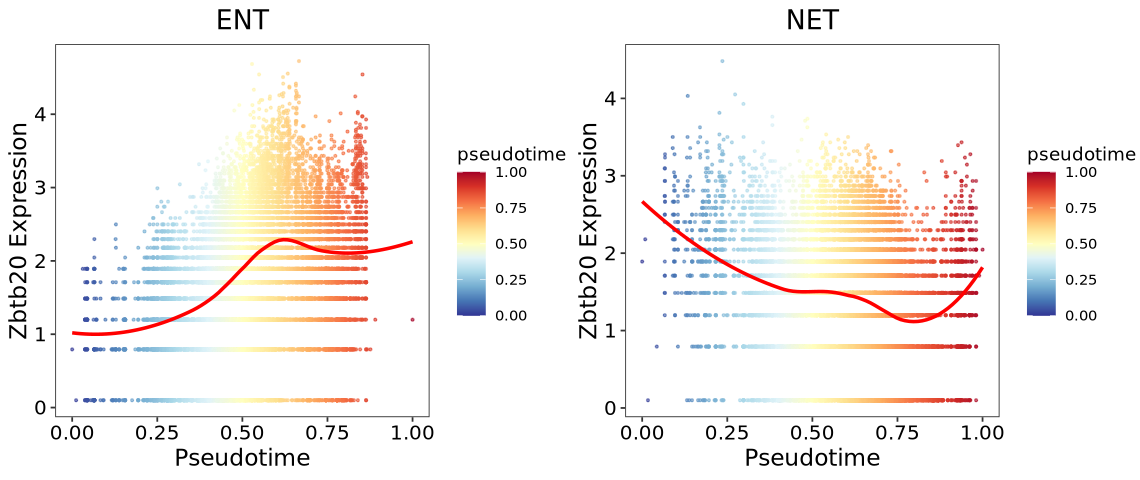

In [43]:
options(repr.plot.width =9.5, repr.plot.height = 4) 
ggarrange(p1,p2,ncol=2)

Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

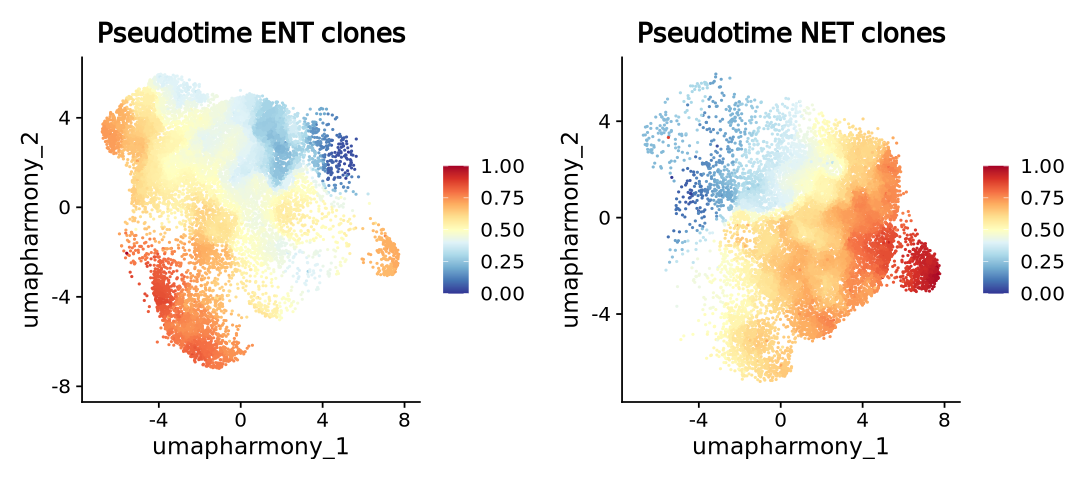

In [44]:
library(RColorBrewer)
options(repr.plot.width = 9, repr.plot.height =4) 
p1 <- FeaturePlot(ent, features = "pseudotime", reduction = "umap.harmony") +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +
  labs(title = "Pseudotime ENT clones")
p2 <- FeaturePlot(net, features = "pseudotime", reduction = "umap.harmony") +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +
  labs(title = "Pseudotime NET clones")
ggarrange(p1,p2,ncol=2)
pdf(file ="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/UMAP_pseudotime.pdf",width =9,height = 4,onefile = TRUE)
ggarrange(p1,p2,ncol=2)
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

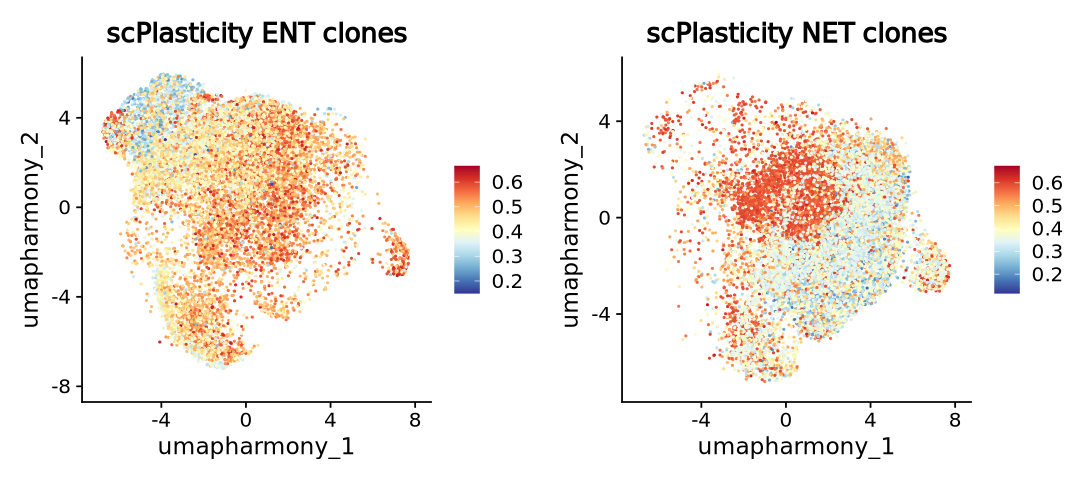

In [46]:
ent@meta.data$scPlasticity <- as.numeric(ent@meta.data$scPlasticity)
net@meta.data$scPlasticity <- as.numeric(net@meta.data$scPlasticity)
options(repr.plot.width = 9, repr.plot.height =4) 
p1 <- FeaturePlot(ent, features = "scPlasticity", reduction = "umap.harmony") +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +
  labs(title = "scPlasticity ENT clones")
p2 <- FeaturePlot(net, features = "scPlasticity", reduction = "umap.harmony") +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +
  labs(title = "scPlasticity NET clones")
ggarrange(p1,p2,ncol=2)
pdf(file ="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/UMAP_scPlasticity.pdf",width =9,height = 4,onefile = TRUE)
ggarrange(p1,p2,ncol=2)
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


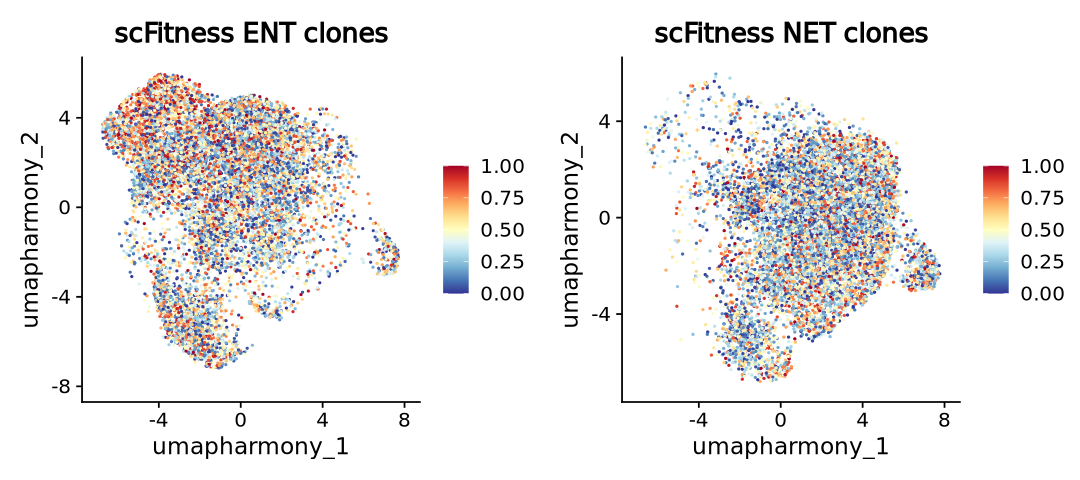

In [176]:
ent@meta.data$scFitness <- as.numeric(ent@meta.data$scFitness)
net@meta.data$scFitness <- as.numeric(net@meta.data$scFitness)
options(repr.plot.width = 9, repr.plot.height =4) 
p1 <- FeaturePlot(ent, features = "scFitness", reduction = "umap.harmony") +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +
  labs(title = "scFitness ENT clones")
p2 <- FeaturePlot(net, features = "scFitness", reduction = "umap.harmony") +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +
  labs(title = "scFitness NET clones")
ggarrange(p1,p2,ncol=2)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


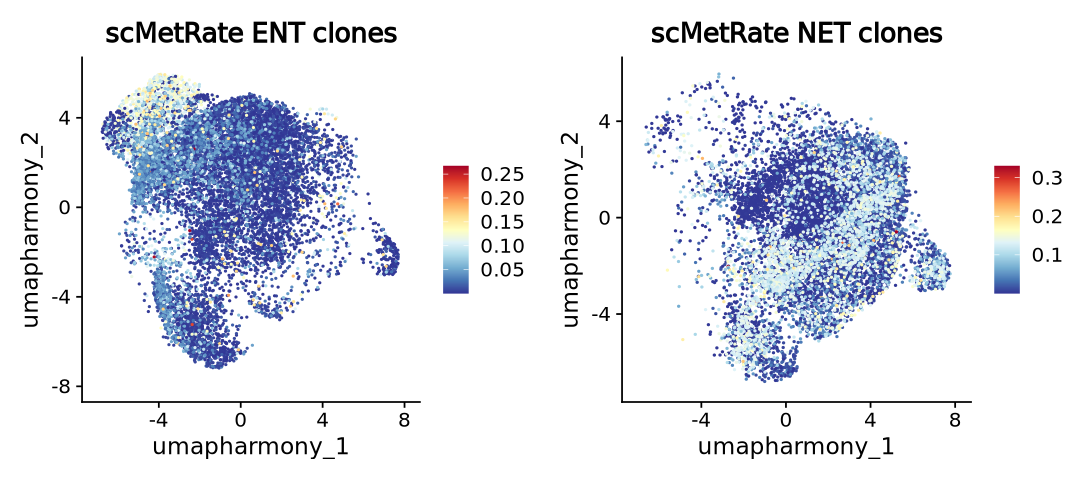

In [178]:
ent@meta.data$scMetRate <- as.numeric(ent@meta.data$scMetRate)
net@meta.data$scMetRate <- as.numeric(net@meta.data$scMetRate)
options(repr.plot.width = 9, repr.plot.height =4) 
p1 <- FeaturePlot(ent, features = "scMetRate", reduction = "umap.harmony") +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +
  labs(title = "scMetRate ENT clones")
p2 <- FeaturePlot(net, features = "scMetRate", reduction = "umap.harmony") +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +
  labs(title = "scMetRate NET clones")
ggarrange(p1,p2,ncol=2)

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


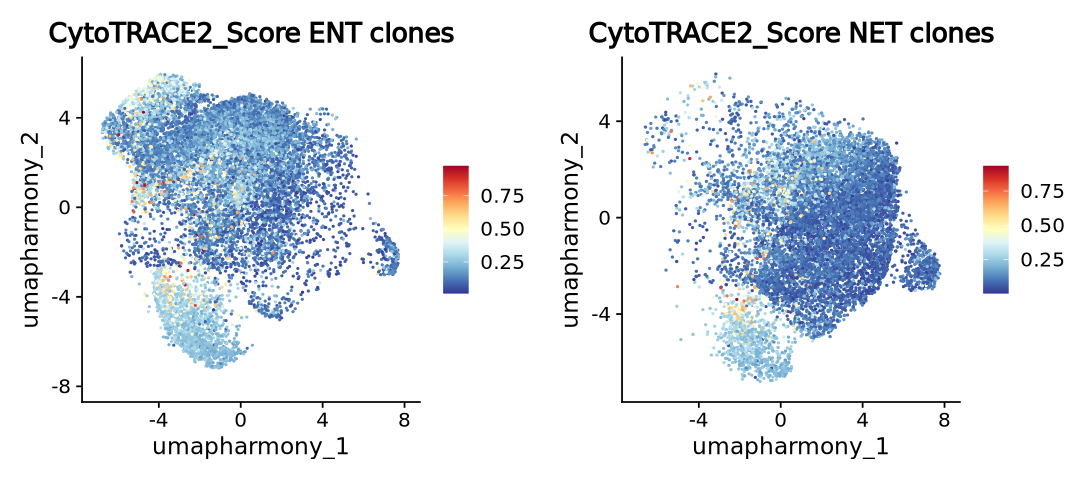

In [180]:
ent@meta.data$CytoTRACE2_Score <- as.numeric(ent@meta.data$CytoTRACE2_Score)
net@meta.data$CytoTRACE2_Score <- as.numeric(net@meta.data$CytoTRACE2_Score)
options(repr.plot.width = 9, repr.plot.height =4) 
p1 <- FeaturePlot(ent, features = "CytoTRACE2_Score", reduction = "umap.harmony") +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +
  labs(title = "CytoTRACE2_Score ENT clones")
p2 <- FeaturePlot(net, features = "CytoTRACE2_Score", reduction = "umap.harmony") +
  scale_color_gradientn(colors = rev(brewer.pal(11, "RdYlBu"))) +
  labs(title = "CytoTRACE2_Score NET clones")
ggarrange(p1,p2,ncol=2)

In [51]:
ent@meta.data$harmony_cluster <- factor(ent@meta.data$harmony_cluster, levels=0:8)
ent <- SetIdent(ent, value=ent@meta.data$harmony_cluster)
net@meta.data$harmony_cluster <- factor(net@meta.data$harmony_cluster, levels=0:8)
net <- SetIdent(net, value=net@meta.data$harmony_cluster)

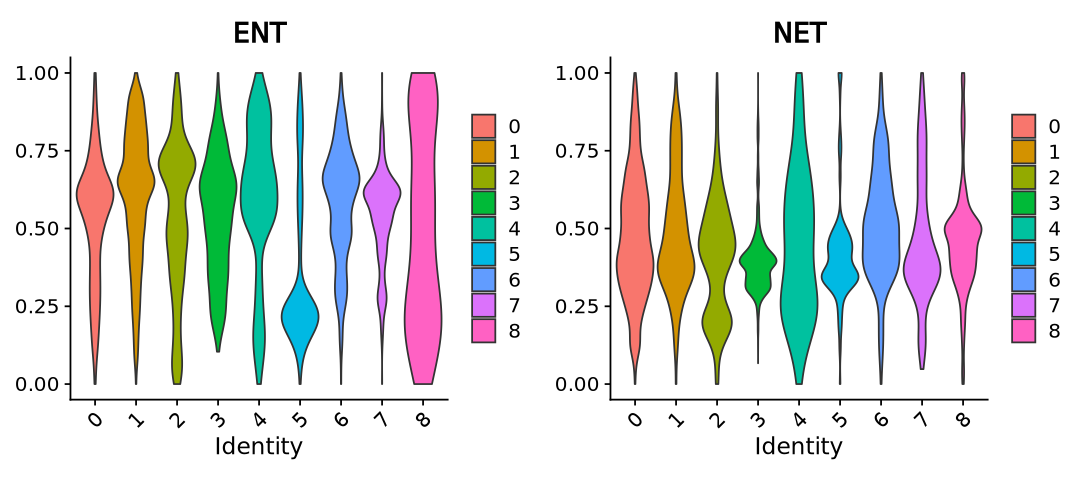

In [56]:
options(repr.plot.width = 9, repr.plot.height = 4) 
p1 <- VlnPlot(ent,features=c('pseudotime'),pt.size=0)+labs(title = "ENT")
p2 <- VlnPlot(net,features=c('pseudotime'),pt.size=0)+labs(title = "NET")
ggarrange(p1,p2,ncol=2)


In [203]:
ent@meta.data[1:2,]

,sampleID,nCount_RNA,nFeature_RNA,percent.mt,percent.ribo,S.Score,G2M.Score,Phase,old.ident,mouse,⋯,MetGroup,scFitness,scPlasticity,scMetRate,Root_to_tip_distance,CytoTRACE2_Score,CytoTRACE2_Potency,CytoTRACE2_Relative,pseudotime,transition
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,⋯,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<chr>
C4007_LLT-1_AAACCCACACAACGAG-1,C4007_LLT-1,22160,6178,0.3925993,19.72473,-0.1619709,-0.2701499,G1,LLT-1,4007,⋯,MetGroup1:Primary-tropic,0.1406313,0.5128302,0.006185988,23.05455,0.12110328,Differentiated,0.121330566801665,0.6995042,ENT
C4007_LLT-1_AAACCCAGTCGCACGT-1,C4007_LLT-1,19050,5655,0.7926509,15.98950,-0.2259478,-0.3126800,G1,LLT-1,4007,⋯,MetGroup1:Primary-tropic,0.7975624,0.5035303,0.004458888,14.1431,0.09428591,Differentiated,0.094270880686444,0.6660539,ENT


Warning message in brewer.pal(11, "Blues"):
“n too large, allowed maximum for palette Blues is 9
Returning the palette you asked for with that many colors
”
Warning message in brewer.pal(11, "Blues"):
“n too large, allowed maximum for palette Blues is 9
Returning the palette you asked for with that many colors
”


pdf 
  2

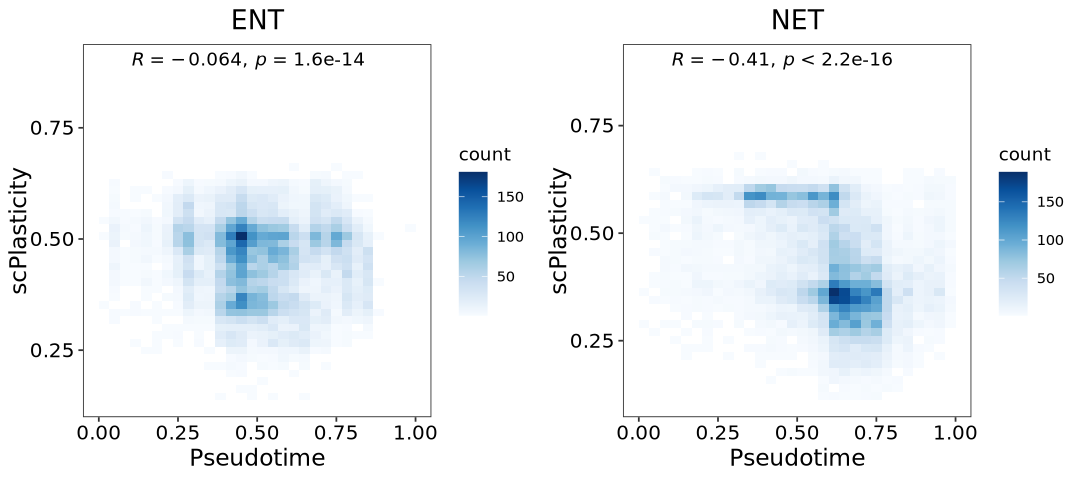

In [48]:
options(repr.plot.width = 9, repr.plot.height = 4) 
p1 <- ggplot(ent@meta.data, aes(pseudotime, scPlasticity)) + 
    geom_bin_2d()+scale_fill_gradientn(colors = brewer.pal(11, "Blues"))+theme_bw()+
    labs(x = "Pseudotime",y = "scPlasticity",title = "ENT") +stat_cor(method = "pearson", label.x = 0.1, label.y = 0.9)+
    theme(panel.grid =element_blank(),
        axis.text.x = element_text(size=12, colour = "black"),
        axis.text.y = element_text(size=12, colour = "black"),
        axis.title.x = element_text(size = 14),axis.title.y = element_text(size = 14),
        plot.title = element_text(size = 16,hjust = 0.5),
    legend.position="right")
p2 <- ggplot(net@meta.data, aes(pseudotime, scPlasticity)) + 
    geom_bin_2d()+scale_fill_gradientn(colors = brewer.pal(11, "Blues"))+theme_bw()+
    labs(x = "Pseudotime",y = "scPlasticity",title = "NET") +stat_cor(method = "pearson", label.x = 0.1, label.y = 0.9)+
    theme(panel.grid =element_blank(),
        axis.text.x = element_text(size=12, colour = "black"),
        axis.text.y = element_text(size=12, colour = "black"),
        axis.title.x = element_text(size = 14),axis.title.y = element_text(size = 14),
        plot.title = element_text(size = 16,hjust = 0.5),
    legend.position="right")
ggarrange(p1,p2,ncol=2)
pdf(file ="/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/pseudotime_vs_scPlasticity.pdf",width =9,height = 4,onefile = TRUE)
ggarrange(p1,p2,ncol=2)
dev.off()

# 2. tradeSeq, 伪时间差异基因，heatmap

In [6]:
library(tradeSeq)
library(Seurat)
library(SingleCellExperiment)
library(ggplot2)
library(enrichR)
library(biomaRt)
library(stringr)
library(pheatmap)
library(dplyr)

# scdata <- readRDS("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/step8.scdata_node_w_scores_pseudotime.rds")
# ent <- subset(scdata, transition=="ENT" & pseudotime !="Others")
# net <- subset(scdata, transition=="NET" & pseudotime !="Others")
# ent@meta.data$pseudotime <- as.numeric(ent@meta.data$pseudotime)
# net@meta.data$pseudotime <- as.numeric(net@meta.data$pseudotime)
# ent
# net

Welcome to enrichR
Checking connections ... 

Enrichr ... 
Connection is Live!

FlyEnrichr ... 
Connection is Live!

WormEnrichr ... 
Connection is Live!

YeastEnrichr ... 
Connection is Live!

FishEnrichr ... 
Connection is Live!

OxEnrichr ... 
Connection is Live!



In [13]:
table(scdata@meta.data[scdata@meta.data$numMut != "Others" & scdata@meta.data$mouse_clone != "Others",]$transition)


   ENT     NA    NET Others 
 14195    263  13751   5575 

In [17]:
table(scdata@meta.data[scdata@meta.data$numMut != "Others" & scdata@meta.data$mouse_clone != "Others",]$mouse_clone)


 4007_1 4007_10 4007_11 4007_12 4007_13 4007_14 4007_15 4007_16 4007_17 4007_18 
     51     586     503      79     631     382     213     459     420     333 
4007_19  4007_2 4007_20 4007_21 4007_23 4007_24 4007_25 4007_26 4007_27 4007_28 
    393    1215      79     214     340     289      76     230     219     242 
4007_29  4007_3 4007_31 4007_32 4007_33 4007_34 4007_35 4007_36 4007_37 4007_38 
    279    1463     180     173     183     205     125      65     134     164 
4007_39  4007_4 4007_40 4007_41 4007_42 4007_43 4007_44 4007_45 4007_46 4007_47 
    155     452      65     121     101      89      76     101      86      62 
4007_48 4007_49  4007_5 4007_50 4007_53 4007_54 4007_55 4007_56 4007_62 4007_63 
     74      79     899      88      57      79      54      75      82      70 
4007_68 4007_69  4007_7 4007_73  4007_8  4007_9 4011_10 4011_11 4011_12 4011_13 
     53      64     331      50     504     701     214     240     199      93 
4011_14 4011_15 4011_16 401

In [40]:
# write.table(scdata@meta.data, "/syn2/zhaolian/3.JiLab/results/2.scRNAseq/4.integrated_byTypeReClustering/matrix_step5/step8.metadata.tsv", sep='\t',row.names=T)

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.0 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.0 GiB”


  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%



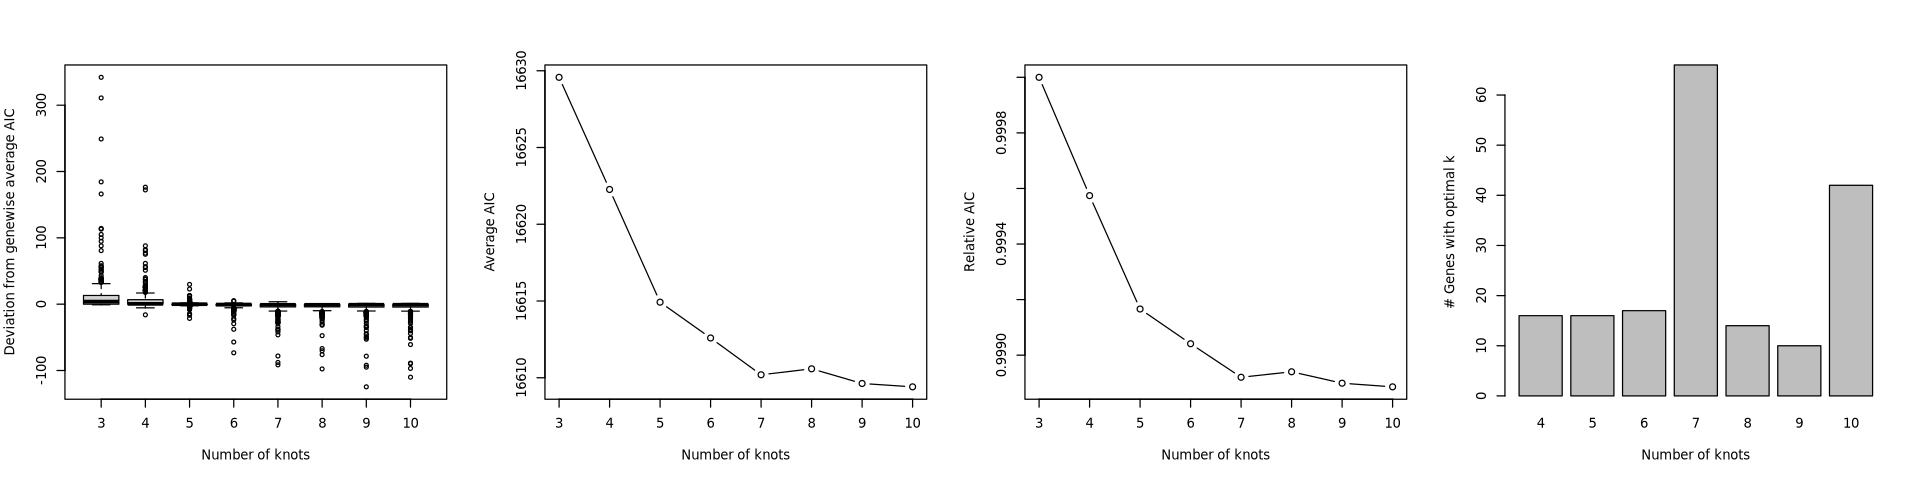

In [19]:
#####################################################################
## net
#####################################################################
# 提取 log-normalized 表达矩阵（gene x cell）
counts <- GetAssayData(net, assay = "RNA", slot = "data")
keep_genes <- rowSums(counts > 0) >= 0.1 * ncol(counts)
counts_filtered <- counts[keep_genes, ]
# 提取伪时间（numeric 向量，长度为细胞数）
pseudotime <- net@meta.data$pseudotime
names(pseudotime) <- colnames(net)
# 构建 cellWeights（如果只有一条轨迹，就设为全1矩阵）
cellWeights <- matrix(1, nrow = length(pseudotime), ncol = 1)
rownames(cellWeights) <- colnames(net)
colnames(cellWeights) <- "curve1"
# 转换 pseudotime 为矩阵
pseudotime_matrix <- matrix(pseudotime, ncol = 1)
rownames(pseudotime_matrix) <- colnames(net)
colnames(pseudotime_matrix) <- "curve1"
###############################################
# choose optimal K
set.seed(12345)
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers <- 30

options(repr.plot.width =16, repr.plot.height = 4) 
icMat <- evaluateK(counts = counts_filtered,pseudotime = pseudotime_matrix,
  cellWeights = cellWeights, k = 3:10, nGenes = 300, verbose = T, parallel=T, BPPARAM = BPPARAM) 

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.1 GiB”
Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 1.1 GiB”


  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%

  |======================================================================| 100%



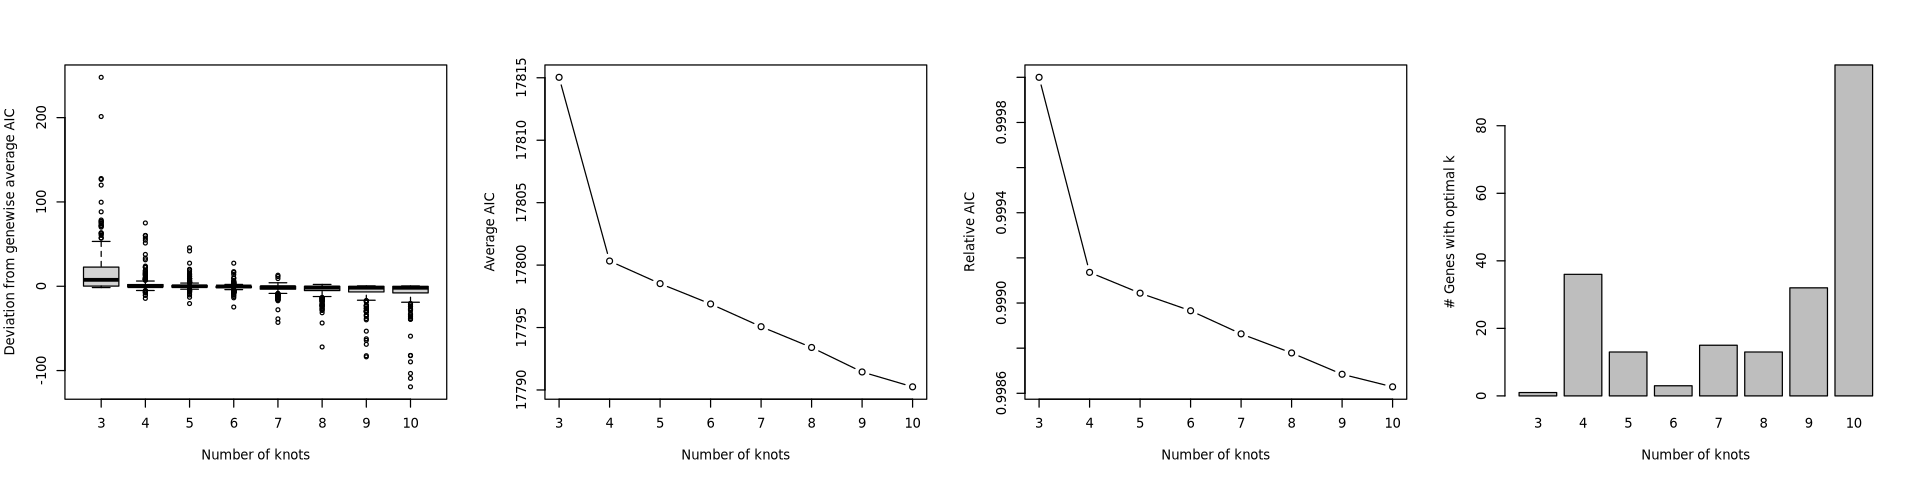

In [20]:
#####################################################################
## ent
#####################################################################
# 提取 log-normalized 表达矩阵（gene x cell）
counts <- GetAssayData(ent, assay = "RNA", slot = "data")
keep_genes <- rowSums(counts > 0) >= 0.1 * ncol(counts)
counts_filtered <- counts[keep_genes, ]
# 提取伪时间（numeric 向量，长度为细胞数）
pseudotime <- ent@meta.data$pseudotime
names(pseudotime) <- colnames(ent)
# 构建 cellWeights（如果只有一条轨迹，就设为全1矩阵）
cellWeights <- matrix(1, nrow = length(pseudotime), ncol = 1)
rownames(cellWeights) <- colnames(ent)
colnames(cellWeights) <- "curve1"
# 转换 pseudotime 为矩阵
pseudotime_matrix <- matrix(pseudotime, ncol = 1)
rownames(pseudotime_matrix) <- colnames(ent)
colnames(pseudotime_matrix) <- "curve1"
###############################################
# choose optimal K
set.seed(12345)
BPPARAM <- BiocParallel::bpparam()
BPPARAM$workers <- 30

options(repr.plot.width =16, repr.plot.height = 4) 
icMat <- evaluateK(counts = counts_filtered,pseudotime = pseudotime_matrix,
  cellWeights = cellWeights, k = 3:10, nGenes = 300, verbose = T, parallel=T, BPPARAM = BPPARAM) 

## 1) fitGAM, submit by slurm

In [236]:
# fit NB models (# knots determined with the evaluateK procedure above)
set.seed(123)
gamModel <- fitGAM(
  counts = counts_filtered,
  pseudotime = pseudotime_matrix,
  cellWeights = cellWeights,
  nknots = 6,
  verbose = TRUE
)
saveRDS(gamModel,"/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/tradeSeq_out_gamModel_NET.rds")
assoRes <- associationTest(gamModel)
saveRDS(assoRes,"/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/tradeSeq_out_assoRes_NET.rds")
head(assoRes)

Warning message in asMethod(object):
“sparse->dense coercion: allocating vector of size 4.8 GiB”


## 2) plot1, NET, knots=5,7

In [3]:
library(tradeSeq)
library(Seurat)
library(SingleCellExperiment)
library(ggplot2)
library(enrichR)
library(biomaRt)
library(stringr)
library(pheatmap)
library(dplyr)

### get smoothed

In [11]:
########################################
## load
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/")
gamModel1 <- readRDS("tradeSeq_out_gamModel_NET_7.rds")
assoRes1<- readRDS("tradeSeq_out_assoRes_NET_7.rds")
########################################
## filter
assoRes1 <- assoRes1[!is.na(assoRes1$waldStat),]
assoRes1['FDR'] = p.adjust(assoRes1$pvalue, method='fdr')
signif.genes1 <- rownames(assoRes1[which( (assoRes1$FDR < 0.05) & (assoRes1$meanLogFC > 0.5)),])
assoResSignif1 <- assoRes1[signif.genes1,]
########################################
## smooth
smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 50)), nrow=1, ncol=50))
smoothed.profiles.lineage2 = t(as.matrix(c(rep(0, 50)), nrow=1, ncol=50))
for (gene in rownames(assoResSignif1)) {
  ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 50)
  smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
}
smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- signif.genes1
write.table(smoothed.profiles.lineage1,file="smoothed.profiles.lineage_NET_7.txt",sep="\t")

### cut clusters

The "ward" method has been renamed to "ward.D"; note new "ward.D2"



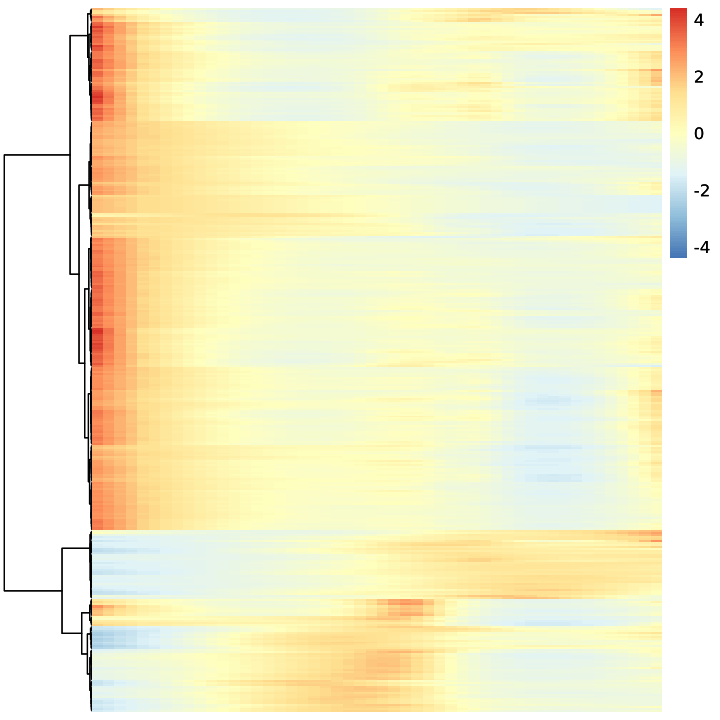

In [12]:
options(repr.plot.width =6, repr.plot.height = 6)
heatmap1 = pheatmap(smoothed.profiles.lineage1, cluster_cols=F, scale='row', show_rownames=F, clustering_method = 'ward',border_color = NA)
heatmap1

The "ward" method has been renamed to "ward.D"; note new "ward.D2"



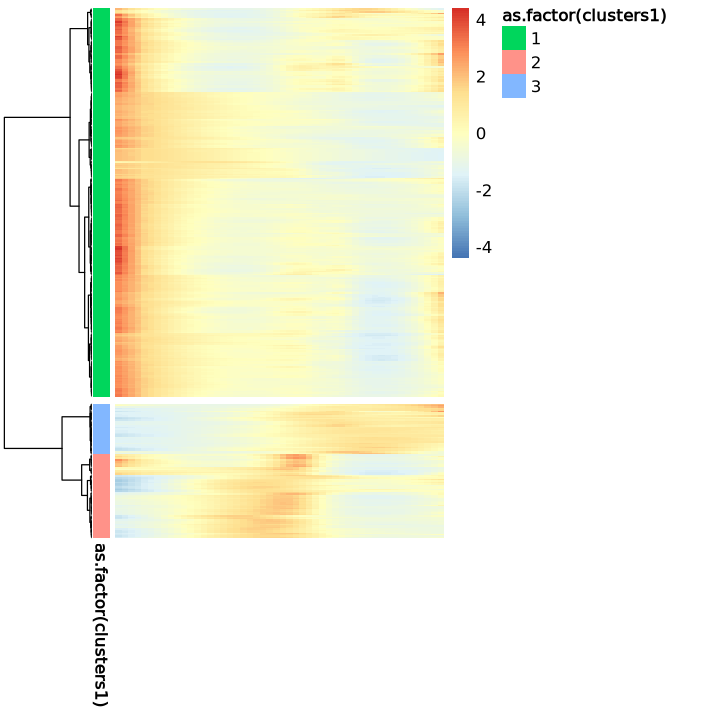

In [13]:
clusters1 = cutree(heatmap1$tree_row,k=3)
heatmap1 = pheatmap(smoothed.profiles.lineage1, cluster_cols=F, scale='row', show_rownames=F, clustering_method = 'ward', cutree_rows = 2,
                    annotation_row = as.data.frame(as.factor(clusters1)),border_color = NA)


### export DE genes

In [14]:
############################################################
## knots=6,6
############################################################
cluster_to_name = list("1"= "Stage1", "2" = "Stage2","3"= "Stage3")
assoResSignif1[,'Cluster'] = sapply(rownames(assoResSignif1), function(x) cluster_to_name[[clusters1[[x]]]])
WRITE = TRUE
write.table(assoResSignif1, "tradeseqDE_NET_7.tsv", sep='\t')

### plot marker gene heatmap

pdf 
  2

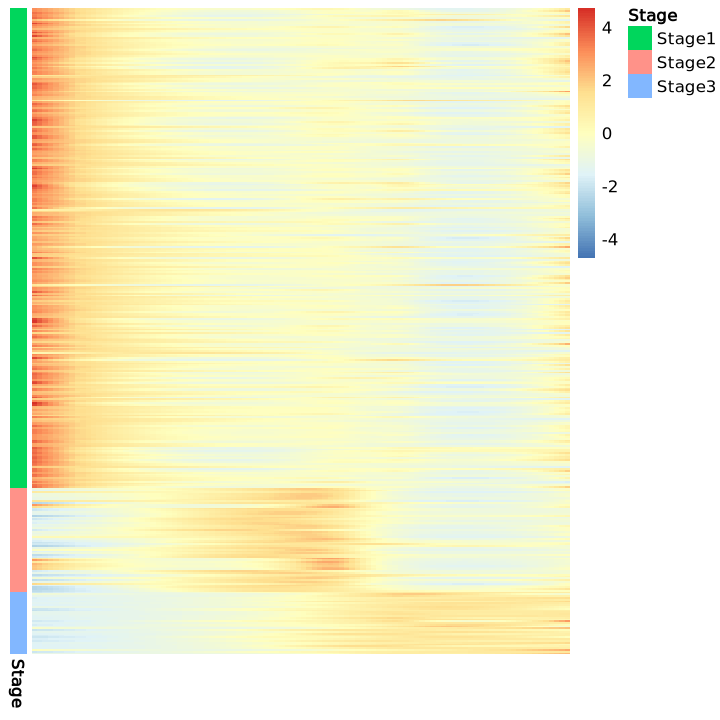

In [15]:
# 获取每个Stage的基因
selected.genes = c(
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage1", ]),
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage2", ]),
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage3", ])
)

# 创建一个名为 cluster.stage 的命名向量
cluster.stage <- setNames(
  rep(c("Stage1", "Stage2", "Stage3"), #, "Stage4", "Stage5"
      times = c(
        sum(assoResSignif1$Cluster == "Stage1"),
        sum(assoResSignif1$Cluster == "Stage2"),
        sum(assoResSignif1$Cluster == "Stage3")
      )),
  selected.genes
)

# 预测平滑表达曲线
smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))
gene.names <- c()

for (gene in unique(selected.genes)) {
  if (gene %in% rownames(gamModel1)) {
    ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 100)
    smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
  }
}

# 移除占位行
smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- gene.names

# 构建 annotation dataframe
annotation_row <- data.frame(Stage = cluster.stage[gene.names])
rownames(annotation_row) <- gene.names

# 画热图
p <- pheatmap(smoothed.profiles.lineage1,
         cluster_cols = FALSE,
         cluster_rows = FALSE,
         scale = 'row',
         show_rownames = FALSE,
         clustering_method = 'ward',
         #cutree_rows = 2,
         annotation_row = annotation_row,border_color = NA)
pdf(file ="Heatmap_DE_genes_NET_7.pdf",width = 5,height =6,onefile = TRUE)
p
dev.off()

In [27]:
getwd()

[1] "/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/byENTandNET"

### enrichR

In [28]:
library(enrichR)
library(biomaRt)
library(gprofiler2)

setEnrichrSite("Enrichr") # Human genes
############################################################
## knots=6
############################################################
assoResSignif1 <- read.delim("tradeseqDE_NET_5.tsv", header=T)
dbs = c("GO_Biological_Process_2018", "ChEA_2016", "MSigDB_Hallmark_2020")
cluster_to_enrichment_NET = list()
cluster_to_enrichment_ENT = list()
for (cluster in unique(assoResSignif1[,'Cluster'])) {
    genes <- rownames(assoResSignif1[assoResSignif1$Cluster == cluster,])
    genes.human = gorth(genes, source_organism = "mmusculus", target_organism = "hsapiens")$ortholog_name
    enrichment = enrichr(genes.human, dbs) 
    write.table(enrichment[[1]], paste0("BP_NET_5_", cluster, '.tsv'), sep='\t',row.names=F, quote=F)
    write.table(enrichment[[2]], paste0("ChEA_NET_5_", cluster, '.tsv'), sep='\t',row.names=F, quote=F)
    write.table(enrichment[[3]], paste0("Hallmark_NET_5_", cluster, '.tsv'), sep='\t',row.names=F, quote=F)
}


Connection changed to https://maayanlab.cloud/Enrichr/

Connection is Live!



Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2018... Done.
  Querying ChEA_2016... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2018... Done.
  Querying ChEA_2016... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2018... Done.
  Querying ChEA_2016... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.


### plot Hallmark

In [29]:
files=list.files(pattern="Hallmark_NET_5_")
length(files)

dt <- data.frame()
for(my.file in files){
    hallmark <- read.delim(my.file, sep = "\t")
    top_hallmark <- hallmark %>%
      arrange(Adjusted.P.value) %>%
      # slice(1:10) %>%  # 如果你只想画每个阶段前10项，可以取消注释这行
      mutate(Term = factor(Term, levels = rev(Term))) %>%
      mutate(GeneCount = sapply(strsplit(Genes, ";"), length))
    
    top_hallmark$stage <- gsub("Hallmark_NET_5_", "", my.file)
    top_hallmark$stage <- gsub(".tsv", "", top_hallmark$stage)
    
    dt <- rbind(dt, top_hallmark)
}

# 确保 Term 在不同facet中顺序一致（可选）
dt$Term <- factor(dt$Term, levels = rev(unique(dt$Term)))

# Plot
options(repr.plot.width = 18, repr.plot.height = 5)

p2 <- ggplot(dt, aes(x = -log10(Adjusted.P.value), y = Term)) +
  geom_point(aes(size = GeneCount, color = Combined.Score)) +
  facet_wrap(~stage, scales = "free",ncol=3) +
  scale_color_viridis_c() +
  labs(
    # title = "Hallmark Enrichment Across Stages",
    x = "-log10(Adjusted P-value)",
    y = NULL,
    size = "Gene Count",
    color = "Combined Score"
  ) +
  theme_minimal(base_size = 14) +
  theme(
    strip.text = element_text(size = 16, face = "bold"),
    axis.text.y = element_text(size = 12)
  )
pdf(file ="Hallmark_NET_5.pdf",width = 15,height =10,onefile = TRUE)
p2
dev.off()

[1] 3

pdf 
  2

In [58]:
files=list.files(pattern="Hallmark_NET_5_")
length(files)
p <- list()
for(my.file in 1:length(files)){
    hallmark <- read.delim(files[my.file], sep = "\t")
    top_hallmark <- hallmark %>%
      arrange(Adjusted.P.value) %>%
      # slice(1:10) %>%  # 如果你只想画每个阶段前10项，可以取消注释这行
      mutate(Term = factor(Term, levels = rev(Term))) %>%
      mutate(GeneCount = sapply(strsplit(Genes, ";"), length))
    
    top_hallmark$stage <- gsub("Hallmark_NET_5_", "", files[my.file])
    top_hallmark$stage <- gsub(".tsv", "", top_hallmark$stage)
    
    p2 <- ggplot(top_hallmark, aes(x = -log10(Adjusted.P.value), y = Term)) +
      geom_point(aes(size = GeneCount, color = Combined.Score)) +
      # facet_wrap(~stage, scales = "free",ncol=3) +
      scale_color_viridis_c() +
      labs(
        title = top_hallmark$stage,
        x = "-log10(Adjusted P-value)",
        y = NULL,
        size = "Gene Count",
        color = "Combined Score"
      ) +
      theme_minimal(base_size = 14) +
      theme(
        strip.text = element_text(size = 16, face = "bold"),
        axis.text.y = element_text(size = 12)
      )
    p[[my.file]] <- p2
}
pdf(file ="Hallmark_NET_5.pdf",width = 18,height =10,onefile = TRUE)
ggarrange(p[[1]],p[[2]],p[[3]],ncol=3)
dev.off()

[1] 3

pdf 
  2

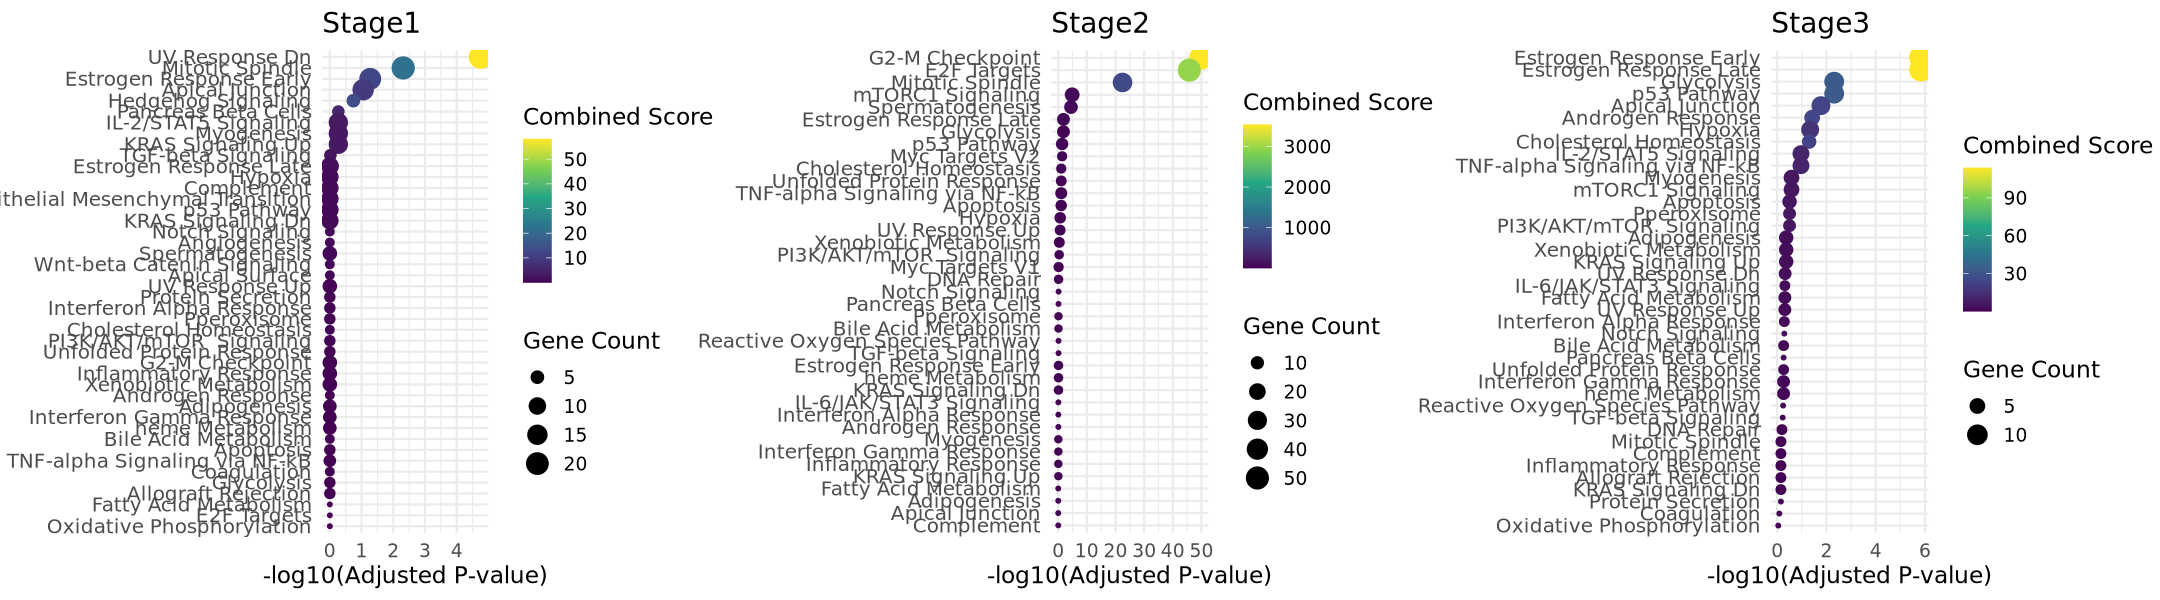

In [59]:
ggarrange(p[[1]],p[[2]],p[[3]],ncol=3)

## 3) plot2, ENT, knots=4,7

### get smoothed

In [21]:
########################################
## load
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/")
gamModel1 <- readRDS("tradeSeq_out_gamModel_ENT_7.rds")
assoRes1<- readRDS("tradeSeq_out_assoRes_ENT_7.rds")
########################################
## filter
assoRes1 <- assoRes1[!is.na(assoRes1$waldStat),]
assoRes1['FDR'] = p.adjust(assoRes1$pvalue, method='fdr')
signif.genes1 <- rownames(assoRes1[which( (assoRes1$FDR < 0.05) & (assoRes1$meanLogFC > 0.5)),])
assoResSignif1 <- assoRes1[signif.genes1,]
########################################
## smooth
smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 50)), nrow=1, ncol=50))
smoothed.profiles.lineage2 = t(as.matrix(c(rep(0, 50)), nrow=1, ncol=50))
for (gene in rownames(assoResSignif1)) {
  ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 50)
  smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
}
smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- signif.genes1
write.table(smoothed.profiles.lineage1,file="smoothed.profiles.lineage_ENT_7.txt",sep="\t")

### cut clusters

The "ward" method has been renamed to "ward.D"; note new "ward.D2"



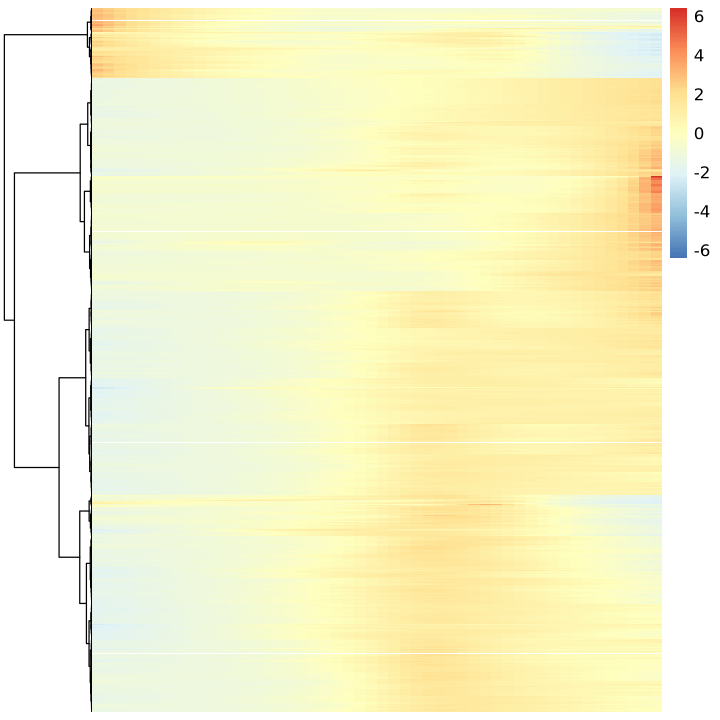

In [22]:
options(repr.plot.width =6, repr.plot.height = 6)
heatmap1 = pheatmap(smoothed.profiles.lineage1, cluster_cols=F, scale='row', show_rownames=F, clustering_method = 'ward',border_color = NA)

The "ward" method has been renamed to "ward.D"; note new "ward.D2"



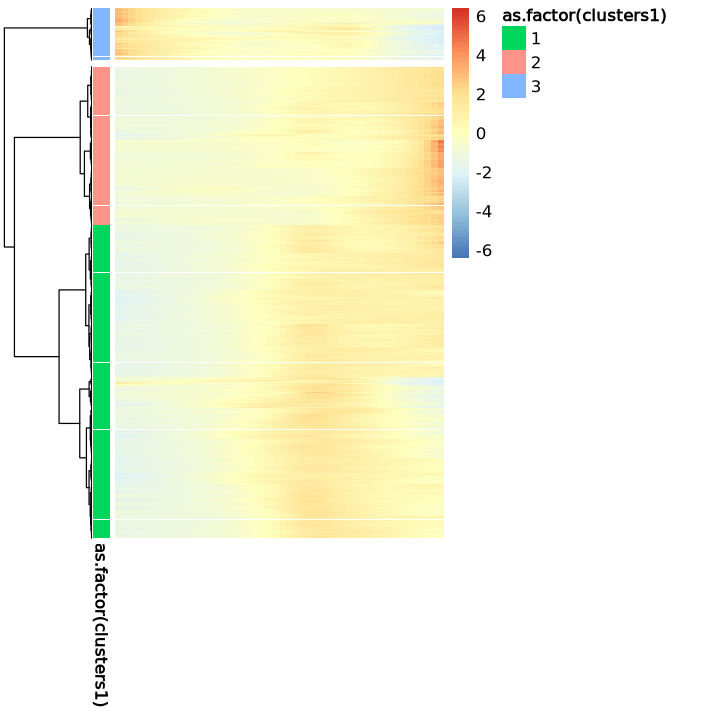

In [23]:
clusters1 = cutree(heatmap1$tree_row,k=3)
heatmap1 = pheatmap(smoothed.profiles.lineage1, cluster_cols=F, scale='row', show_rownames=F, clustering_method = 'ward', cutree_rows = 2,
                    annotation_row = as.data.frame(as.factor(clusters1)),border_color = NA)


### export DE genes

In [24]:
############################################################
## knots=6,6
############################################################
cluster_to_name = list("1"= "Stage2", "2" = "Stage3","3"= "Stage1")
assoResSignif1[,'Cluster'] = sapply(rownames(assoResSignif1), function(x) cluster_to_name[[clusters1[[x]]]])
WRITE = TRUE
write.table(assoResSignif1, "tradeseqDE_ENT_7.tsv", sep='\t')

### plot marker gene heatmap

pdf 
  2

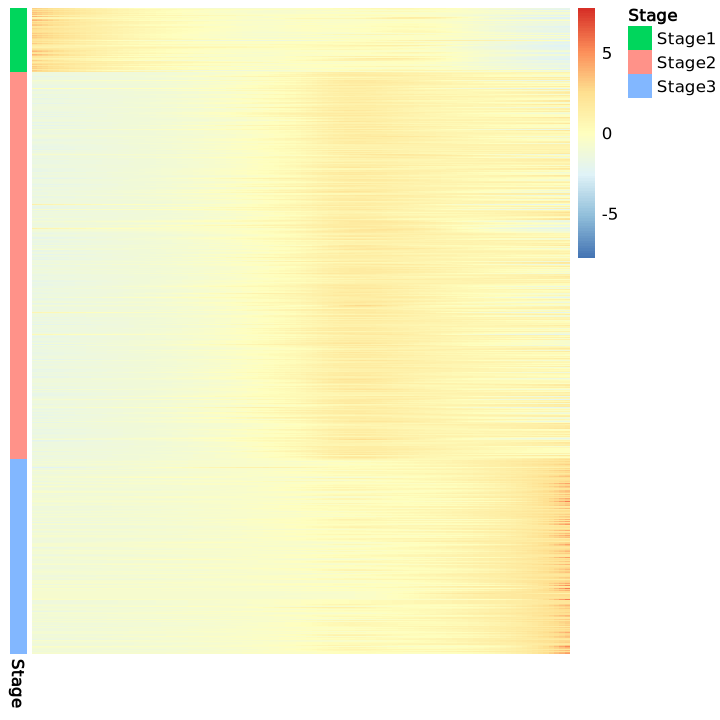

In [25]:
# 获取每个Stage的基因
selected.genes = c(
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage1", ]),
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage2", ]),
  row.names(assoResSignif1[assoResSignif1$Cluster == "Stage3", ])
)

# 创建一个名为 cluster.stage 的命名向量
cluster.stage <- setNames(
  rep(c("Stage1", "Stage2", "Stage3"), #, "Stage4", "Stage5"
      times = c(
        sum(assoResSignif1$Cluster == "Stage1"),
        sum(assoResSignif1$Cluster == "Stage2"),
        sum(assoResSignif1$Cluster == "Stage3")
      )),
  selected.genes
)

# 预测平滑表达曲线
smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))
gene.names <- c()

for (gene in unique(selected.genes)) {
  if (gene %in% rownames(gamModel1)) {
    ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 100)
    smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
  }
}

# 移除占位行
smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- gene.names

# 构建 annotation dataframe
annotation_row <- data.frame(Stage = cluster.stage[gene.names])
rownames(annotation_row) <- gene.names

# 画热图
p <- pheatmap(smoothed.profiles.lineage1,
         cluster_cols = FALSE,
         cluster_rows = FALSE,
         scale = 'row',
         show_rownames = FALSE,
         clustering_method = 'ward',
         cutree_rows = 2,
         annotation_row = annotation_row,border_color = NA)
pdf(file ="Heatmap_DE_genes_ENT_7.pdf",width = 5,height =6,onefile = TRUE)
p
dev.off()

### enrichR

In [32]:
library(enrichR)
library(biomaRt)
library(gprofiler2)

setEnrichrSite("Enrichr") # Human genes
############################################################
## knots=6
############################################################
assoResSignif1 <- read.delim("tradeseqDE_ENT_7.tsv", header=T)
dbs = c("GO_Biological_Process_2018", "ChEA_2016", "MSigDB_Hallmark_2020")
cluster_to_enrichment_NET = list()
cluster_to_enrichment_ENT = list()
for (cluster in unique(assoResSignif1[,'Cluster'])) {
    genes <- rownames(assoResSignif1[assoResSignif1$Cluster == cluster,])
    genes.human = gorth(genes, source_organism = "mmusculus", target_organism = "hsapiens")$ortholog_name
    enrichment = enrichr(genes.human, dbs) 
    write.table(enrichment[[1]], paste0("BP_ENT_7_", cluster, '.tsv'), sep='\t',row.names=F, quote=F)
    write.table(enrichment[[2]], paste0("ChEA_ENT_7_", cluster, '.tsv'), sep='\t',row.names=F, quote=F)
    write.table(enrichment[[3]], paste0("Hallmark_ENT_7_", cluster, '.tsv'), sep='\t',row.names=F, quote=F)
}


Connection changed to https://maayanlab.cloud/Enrichr/

Connection is Live!



Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2018... Done.
  Querying ChEA_2016... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2018... Done.
  Querying ChEA_2016... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.
Uploading data to Enrichr... Done.
  Querying GO_Biological_Process_2018... Done.
  Querying ChEA_2016... Done.
  Querying MSigDB_Hallmark_2020... Done.
Parsing results... Done.


### plot Hallmark

In [60]:
files=list.files(pattern="Hallmark_ENT_7_")
length(files)
p <- list()
for(my.file in 1:length(files)){
    hallmark <- read.delim(files[my.file], sep = "\t")
    top_hallmark <- hallmark %>%
      arrange(Adjusted.P.value) %>%
      # slice(1:10) %>%  # 如果你只想画每个阶段前10项，可以取消注释这行
      mutate(Term = factor(Term, levels = rev(Term))) %>%
      mutate(GeneCount = sapply(strsplit(Genes, ";"), length))
    
    top_hallmark$stage <- gsub("Hallmark_ENT_7_", "", files[my.file])
    top_hallmark$stage <- gsub(".tsv", "", top_hallmark$stage)
    
    p2 <- ggplot(top_hallmark, aes(x = -log10(Adjusted.P.value), y = Term)) +
      geom_point(aes(size = GeneCount, color = Combined.Score)) +
      # facet_wrap(~stage, scales = "free",ncol=3) +
      scale_color_viridis_c() +
      labs(
        title = top_hallmark$stage,
        x = "-log10(Adjusted P-value)",
        y = NULL,
        size = "Gene Count",
        color = "Combined Score"
      ) +
      theme_minimal(base_size = 14) +
      theme(
        strip.text = element_text(size = 16, face = "bold"),
        axis.text.y = element_text(size = 12)
      )
    p[[my.file]] <- p2
}
pdf(file ="Hallmark_ENT_7.pdf",width = 18,height =10,onefile = TRUE)
ggarrange(p[[1]],p[[2]],p[[3]],ncol=3)
dev.off()

[1] 3

pdf 
  2

## 4) plot SCENIC TFs

In [3]:
regulon_orders <- c("Elf3","Zfp551","Irf7","Atf3","Xbp1","Fos","Maff","Irf9","Ets2","Junb","Fosb","Atf4","Jund","Rfx3","Ybx1","Jun",
                    "Zfp148","Nfib","Klf7","Yy1","Sox9","E2f2","Mxd3",
                    "Zeb1","E2f7","Tcf7l2","Zfp367","Ctcf","Pbx1","Lcorl","Ilf2","Taf1","Bptf","Mycn","Zfp704","Elf2","Clock",
                    "Chd1","Tcf12","Zbtb20")

pdf 
  2

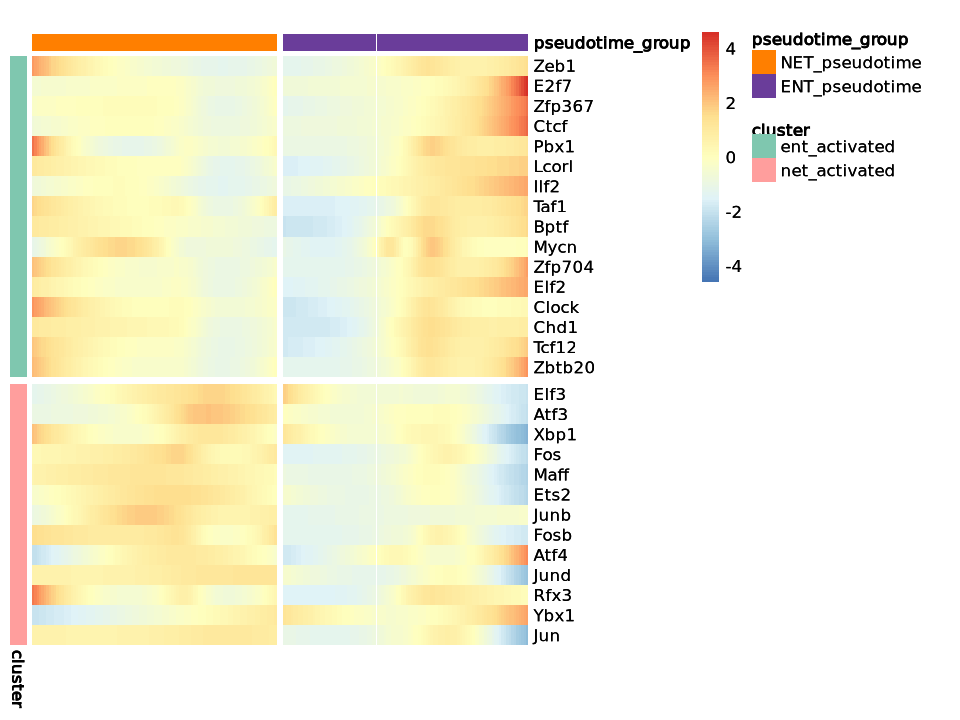

In [9]:
############ Plot marker gene heatmaps ########################
net.genes = regulon_orders[1:16]
hybrid.genes = regulon_orders[17:23]
ent.genes = regulon_orders[24:length(regulon_orders)]

setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/")
gamModel1 <- readRDS("tradeSeq_out_gamModel_NET_5.rds")
assoRes1<- readRDS("tradeSeq_out_assoRes_NET_5.rds")
assoResSignif1 <- read.delim("tradeseqDE_NET_5.tsv", header=T)

gamModel2 <- readRDS("tradeSeq_out_gamModel_ENT_7.rds")
assoRes2<- readRDS("tradeSeq_out_assoRes_ENT_7.rds")
assoResSignif2 <- read.delim("tradeseqDE_ENT_7.tsv", header=T)

smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))
smoothed.profiles.lineage2 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))

gene.names <- c()
for (gene in unique(c(net.genes, ent.genes))) {#hybrid.genes, 
  if (gene %in% rownames(gamModel1)) {
    ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 100)
    smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
    }
}
smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- gene.names

gene.names <- c()
for (gene in unique(c(net.genes, ent.genes))) {#hybrid.genes, 
  if (gene %in% rownames(gamModel2)) {
    ysmoothed = predictSmooth(models = gamModel2, gene = gene, nPoints = 100)
    smoothed.profiles.lineage2 = rbind(smoothed.profiles.lineage2, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
    }
}
smoothed.profiles.lineage2 = smoothed.profiles.lineage2[-1,]
rownames(smoothed.profiles.lineage2) <- gene.names
###################################################################
## row annotations
fate.gene.annotations = data.frame(cluster = rep('Hybrid', length(hybrid.genes)))
rownames(fate.gene.annotations) <- hybrid.genes

uniq.net = net.genes[net.genes %in% rownames(smoothed.profiles.lineage1)]
hybrid.fate=hybrid.genes[hybrid.genes %in% rownames(smoothed.profiles.lineage1)]
uniq.ent = ent.genes[ent.genes %in% rownames(smoothed.profiles.lineage2)]
fate.gene.annotations = rbind(data.frame(cluster = rep('ent_activated', length(uniq.ent)), row.names=uniq.ent),
                              #data.frame(cluster = rep('hybrid', length(hybrid.fate)), row.names=hybrid.fate),
                              data.frame(cluster = rep('net_activated', length(uniq.net)), row.names=uniq.net))

###################################################################
## column annotations
annotation_col <- data.frame(
  pseudotime_group = c(rep("NET_pseudotime", 100),
                       rep("ENT_pseudotime", 100))
)
# rownames(annotation_col) <- colnames(total.smoothed.profiles)
# 自定义颜色（可选）  
ann_colors <- list(
  cluster = c(ent_activated = "#7FC7AFFF", net_activated = "#FF9E9DFF"),#hybrid = "#DAD8A7FF", 
  pseudotime_group = c(NET_pseudotime = "#ff7f00", ENT_pseudotime = "#6a3d9a")
)

total.smoothed.profiles = merge(smoothed.profiles.lineage1, smoothed.profiles.lineage2,by=0, all=TRUE)
total.smoothed.profiles[is.na(total.smoothed.profiles)] = 0
rownames(total.smoothed.profiles) <- total.smoothed.profiles$Row.names
total.smoothed.profiles <- total.smoothed.profiles[,-1]
rownames(annotation_col) <- colnames(total.smoothed.profiles)
heatmap.total = pheatmap(total.smoothed.profiles[rownames(fate.gene.annotations),], 
                         cluster_cols=F, cluster_rows=F, scale='row', show_rownames=T, clustering_method = 'ward', show_colnames = F,
                         annotation_row = fate.gene.annotations, annotation_col = annotation_col,annotation_colors = ann_colors,
                         main='', gaps_col=100, gaps_row=16)
options(repr.plot.width =8, repr.plot.height = 6)
heatmap.total

pdf(file ="Regulon_TF_heatmap_net5_ent7-2.pdf",width = 8,height =6,onefile = TRUE)
heatmap.total
dev.off()

## 5) plot selected genes

[1] "Adm"      "Ak4"      "Aldoc"    "Atp7b"    "Bhlhe40"  "Bnip3"   
 [7] "Egr3"     "Fbxl21"   "Gm15283"  "Gm21981"  "Gm27232"  "Hk2"     
[13] "Igfbp2"   "Kif19a"   "Lamb1"    "Lrp2bp"   "Mapkapk3" "Mgarp"   
[19] "Ndrg1"    "Ndrg2"    "Pfkfb3"   "Pygl"     "Selenbp1" "Selenbp2"
[25] "Sema4g"   "Smtnl2"   "Srcin1"   "Stab2"    "Stc1"

character(0)

pdf 
  2

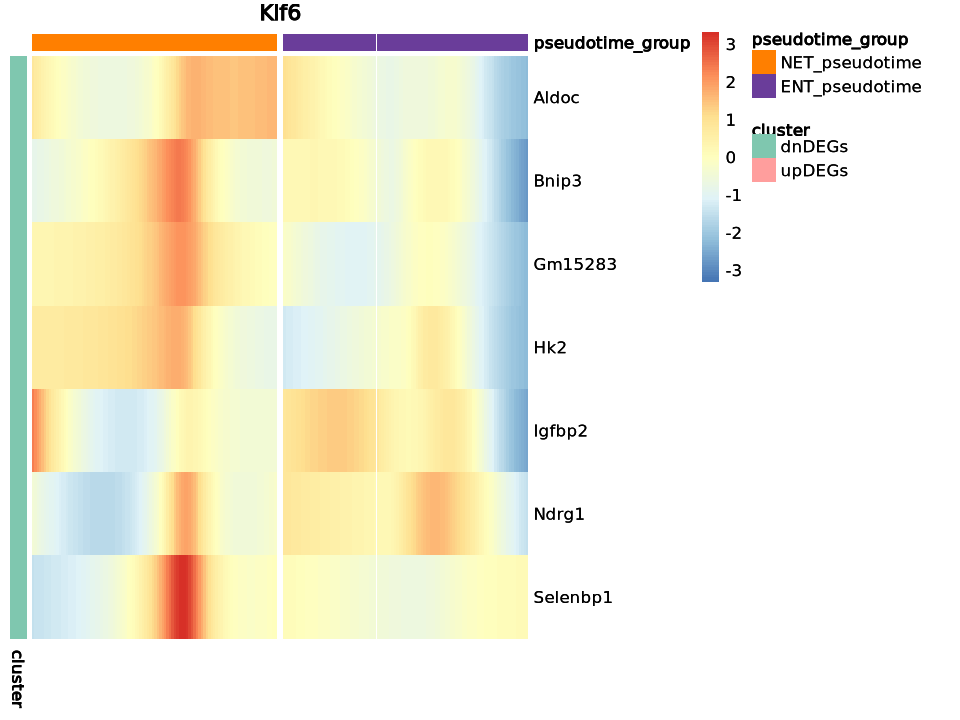

In [72]:
genes=c("Zeb1","Fhl2","Klf2","Klf6")
my.gene=genes[4]
degs <- read.delim(paste0("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/DEGs_gene_overexpression/DEGs_",my.gene,"_overexpression.txt"),header=T)
dngenes=degs[degs$sig=="dnDEGs",]$gene
upgenes=degs[degs$sig=="upDEGs",]$gene
dngenes
upgenes

############ Plot marker gene heatmaps ########################
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/")
# gamModel1 <- readRDS("tradeSeq_out_gamModel_NET_5.rds")
# assoRes1<- readRDS("tradeSeq_out_assoRes_NET_5.rds")
# assoResSignif1 <- read.delim("tradeseqDE_NET_5.tsv", header=T)

# gamModel2 <- readRDS("tradeSeq_out_gamModel_ENT_7.rds")
# assoRes2<- readRDS("tradeSeq_out_assoRes_ENT_7.rds")
# assoResSignif2 <- read.delim("tradeseqDE_ENT_7.tsv", header=T)

smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))
smoothed.profiles.lineage2 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))

gene.names <- c()
for (gene in unique(c(upgenes, dngenes))) {
  if (gene %in% rownames(gamModel1)) {
    ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 100)
    smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
    }
}
smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- gene.names

gene.names <- c()
for (gene in unique(c(upgenes, dngenes))) {
  if (gene %in% rownames(gamModel2)) {
    ysmoothed = predictSmooth(models = gamModel2, gene = gene, nPoints = 100)
    smoothed.profiles.lineage2 = rbind(smoothed.profiles.lineage2, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
    }
}
smoothed.profiles.lineage2 = smoothed.profiles.lineage2[-1,]
rownames(smoothed.profiles.lineage2) <- gene.names


###################################################################
## row annotations
uniq.up = upgenes[upgenes %in% rownames(smoothed.profiles.lineage1)]
uniq.dn = dngenes[dngenes %in% rownames(smoothed.profiles.lineage2)]
fate.gene.annotations = rbind(data.frame(cluster = rep('dnDEGs', length(uniq.dn)), row.names=uniq.dn),
                              
                              data.frame(cluster = rep('upDEGs', length(uniq.up)), row.names=uniq.up))

###################################################################
## column annotations
annotation_col <- data.frame(
  pseudotime_group = c(rep("NET_pseudotime", 100),
                       rep("ENT_pseudotime", 100))
)
# rownames(annotation_col) <- colnames(total.smoothed.profiles)
# 自定义颜色（可选）  
ann_colors <- list(
  cluster = c(dnDEGs = "#7FC7AFFF", upDEGs = "#FF9E9DFF"),
  pseudotime_group = c(NET_pseudotime = "#ff7f00", ENT_pseudotime = "#6a3d9a")
)

total.smoothed.profiles = merge(smoothed.profiles.lineage1, smoothed.profiles.lineage2,by=0, all=TRUE)
total.smoothed.profiles[is.na(total.smoothed.profiles)] = 0
rownames(total.smoothed.profiles) <- total.smoothed.profiles$Row.names
total.smoothed.profiles <- total.smoothed.profiles[,-1]
rownames(annotation_col) <- colnames(total.smoothed.profiles)
heatmap.total = pheatmap(total.smoothed.profiles[rownames(fate.gene.annotations),], 
                         cluster_cols=F, cluster_rows=F, scale='row', show_rownames=T, clustering_method = 'ward', show_colnames = F,
                         annotation_row = fate.gene.annotations, annotation_col = annotation_col,annotation_colors = ann_colors,
                         main=my.gene, gaps_col=100, gaps_row=length(uniq.dn))
options(repr.plot.width =8, repr.plot.height = 6)
heatmap.total

pdf(file =paste0("DEGs_gene_overexpression/tradeSeq_Heatmap_",my.gene,"overexpression.pdf"),width = 8,height =4,onefile = TRUE)
heatmap.total
dev.off()

In [57]:
genes=c("Zeb1","Fhl2","Klf2","Klf6")
my.gene=genes[2]
degs <- read.delim(paste0("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/DEGs_gene_overexpression/DEGs_",my.gene,"_overexpression.txt"),header=T)
dngenes=degs[degs$sig=="dnDEGs",]$gene
upgenes=degs[degs$sig=="upDEGs",]$gene
dngenes
upgenes

############ Plot marker gene heatmaps ########################
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/")
# gamModel1 <- readRDS("tradeSeq_out_gamModel_NET_5.rds")
# assoRes1<- readRDS("tradeSeq_out_assoRes_NET_5.rds")
# assoResSignif1 <- read.delim("tradeseqDE_NET_5.tsv", header=T)

# gamModel2 <- readRDS("tradeSeq_out_gamModel_ENT_7.rds")
# assoRes2<- readRDS("tradeSeq_out_assoRes_ENT_7.rds")
# assoResSignif2 <- read.delim("tradeseqDE_ENT_7.tsv", header=T)

smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))
smoothed.profiles.lineage2 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))

gene.names <- c()
for (gene in unique(c(my.gene,upgenes, dngenes))) {
  if (gene %in% rownames(gamModel1)) {
    ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 100)
    smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
    }
}
smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- gene.names

gene.names <- c()
for (gene in unique(c(my.gene,upgenes, dngenes))) {
  if (gene %in% rownames(gamModel2)) {
    ysmoothed = predictSmooth(models = gamModel2, gene = gene, nPoints = 100)
    smoothed.profiles.lineage2 = rbind(smoothed.profiles.lineage2, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
    }
}
smoothed.profiles.lineage2 = smoothed.profiles.lineage2[-1,]
rownames(smoothed.profiles.lineage2) <- gene.names



[1] "Prelp"

[1] "C530043K16Rik" "Gm42892"       "Rab26os"       "Tgfbr3l"

pdf 
  2

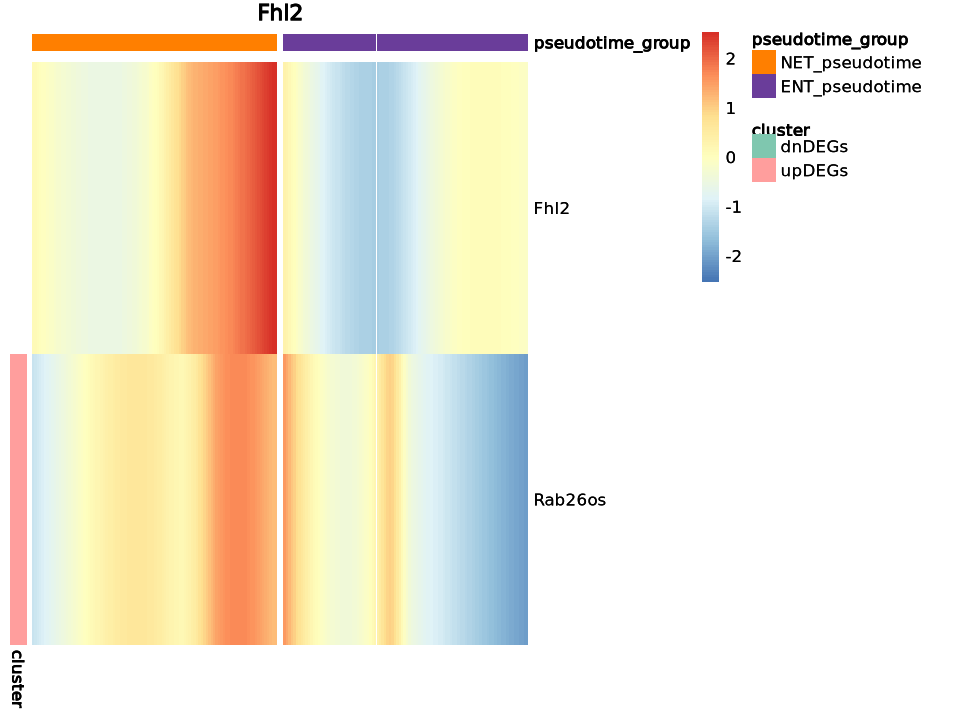

In [69]:
###################################################################
## row annotations
uniq.up = upgenes[upgenes %in% rownames(smoothed.profiles.lineage1)]
uniq.dn = dngenes[dngenes %in% rownames(smoothed.profiles.lineage2)]
fate.gene.annotations = rbind(data.frame(cluster = rep('dnDEGs', length(uniq.dn)), row.names=uniq.dn),
                              data.frame(cluster = rep('upDEGs', length(uniq.up)), row.names=uniq.up))

###################################################################
## column annotations
annotation_col <- data.frame(
  pseudotime_group = c(rep("NET_pseudotime", 100),
                       rep("ENT_pseudotime", 100))
)
# rownames(annotation_col) <- colnames(total.smoothed.profiles)
# 自定义颜色（可选）  
ann_colors <- list(
  cluster = c(dnDEGs = "#7FC7AFFF", upDEGs = "#FF9E9DFF"),
  pseudotime_group = c(NET_pseudotime = "#ff7f00", ENT_pseudotime = "#6a3d9a")
)

total.smoothed.profiles = merge(smoothed.profiles.lineage1, smoothed.profiles.lineage2,by=0, all=TRUE)
total.smoothed.profiles[is.na(total.smoothed.profiles)] = 0
rownames(total.smoothed.profiles) <- total.smoothed.profiles$Row.names
total.smoothed.profiles <- total.smoothed.profiles[,-1]
rownames(annotation_col) <- colnames(total.smoothed.profiles)
heatmap.total = pheatmap(total.smoothed.profiles,#[rownames(fate.gene.annotations),], 
                         cluster_cols=F, cluster_rows=F, scale='row', show_rownames=T, clustering_method = 'ward', show_colnames = F,
                         annotation_row = fate.gene.annotations, annotation_col = annotation_col,annotation_colors = ann_colors,
                         main=my.gene, gaps_col=100, gaps_row=length(uniq.dn))
options(repr.plot.width =8, repr.plot.height = 6)
heatmap.total

pdf(file =paste0("DEGs_gene_overexpression/tradeSeq_Heatmap_",my.gene,"overexpression.pdf"),width = 8,height =3,onefile = TRUE)
heatmap.total
dev.off()

In [ ]:
genes=c("Zeb1","Fhl2","Klf2","Klf6")

############ Plot marker gene heatmaps ########################
setwd("/syn2/zhaolian/3.JiLab/results/2.scRNAseq/6.3.phylovelo/")
# gamModel1 <- readRDS("tradeSeq_out_gamModel_NET_5.rds")
# assoRes1<- readRDS("tradeSeq_out_assoRes_NET_5.rds")
# assoResSignif1 <- read.delim("tradeseqDE_NET_5.tsv", header=T)

# gamModel2 <- readRDS("tradeSeq_out_gamModel_ENT_7.rds")
# assoRes2<- readRDS("tradeSeq_out_assoRes_ENT_7.rds")
# assoResSignif2 <- read.delim("tradeseqDE_ENT_7.tsv", header=T)

smoothed.profiles.lineage1 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))
smoothed.profiles.lineage2 = t(as.matrix(c(rep(0, 100)), nrow=1, ncol=100))

gene.names <- c()
for (gene in genes) {
  if (gene %in% rownames(gamModel1)) {
    ysmoothed = predictSmooth(models = gamModel1, gene = gene, nPoints = 100)
    smoothed.profiles.lineage1 = rbind(smoothed.profiles.lineage1, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
    }
}
smoothed.profiles.lineage1 = smoothed.profiles.lineage1[-1,]
rownames(smoothed.profiles.lineage1) <- gene.names

gene.names <- c()
for (gene in genes) {
  if (gene %in% rownames(gamModel2)) {
    ysmoothed = predictSmooth(models = gamModel2, gene = gene, nPoints = 100)
    smoothed.profiles.lineage2 = rbind(smoothed.profiles.lineage2, ysmoothed[, 'yhat'])
    gene.names <- c(gene.names, gene)
    }
}
smoothed.profiles.lineage2 = smoothed.profiles.lineage2[-1,]
rownames(smoothed.profiles.lineage2) <- gene.names


###################################################################
## column annotations
annotation_col <- data.frame(
  pseudotime_group = c(rep("NET_pseudotime", 100),
                       rep("ENT_pseudotime", 100))
)
# rownames(annotation_col) <- colnames(total.smoothed.profiles)
# 自定义颜色（可选）  
ann_colors <- list(
  pseudotime_group = c(NET_pseudotime = "#ff7f00", ENT_pseudotime = "#6a3d9a")
)

total.smoothed.profiles = merge(smoothed.profiles.lineage1, smoothed.profiles.lineage2,by=0, all=TRUE)
total.smoothed.profiles[is.na(total.smoothed.profiles)] = 0
rownames(total.smoothed.profiles) <- total.smoothed.profiles$Row.names
total.smoothed.profiles <- total.smoothed.profiles[,-1]
rownames(annotation_col) <- colnames(total.smoothed.profiles)
heatmap.total = pheatmap(total.smoothed.profiles, 
                         cluster_cols=F, cluster_rows=F, scale='row', show_rownames=T, clustering_method = 'ward', show_colnames = F,
                         annotation_col = annotation_col,annotation_colors = ann_colors,
                         main=my.gene, gaps_col=100)
options(repr.plot.width =8, repr.plot.height = 6)
heatmap.total

pdf(file =paste0("DEGs_gene_overexpression/tradeSeq_Heatmap_targeted_gene_overexpression.pdf"),width = 8,height =4,onefile = TRUE)
heatmap.total
dev.off()

In [84]:
pdf(file =paste0("DEGs_gene_overexpression/tradeSeq_Heatmap_targeted_gene_overexpression.pdf"),width = 8,height =4,onefile = TRUE)
heatmap.total
dev.off()

pdf 
  2

pdf 
  2

# 2. Monocle

In [187]:
scdata@meta.data$CytoTRACE2_Score <- as.numeric(scdata@meta.data$CytoTRACE2_Score)

In [189]:
sub <- subset(scdata, CytoTRACE2_Potency != "Others")
sub@meta.data$CytoTRACE2_Potency <- factor(sub@meta.data$CytoTRACE2_Potency, 
                                           levels=c("Totipotent","Pluripotent","Multipotent","Oligopotent","Unipotent","Differentiated"))

In [197]:
table(sub@meta.data$CytoTRACE2_Potency)


Differentiated    Multipotent    Oligopotent    Pluripotent     Totipotent 
        101042           2309           6473            529            133 
     Unipotent 
         43981 

In [196]:
table(sub@meta.data$harmony_cluster)


    0     1     2     3     4     5     6     7     8 
49098 34751 15923 15728 12201 11022  6392  5548  3804 

In [192]:
sub@meta.data$harmony_cluster <- factor(sub@meta.data$harmony_cluster,levels=0:8)

Warning message in SetQuantile(cutoff = min.cutoff[f], data = data.feature):
“NAs introduced by coercion”
Warning message in SetQuantile(cutoff = max.cutoff[f], data = data.feature):
“NAs introduced by coercion”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


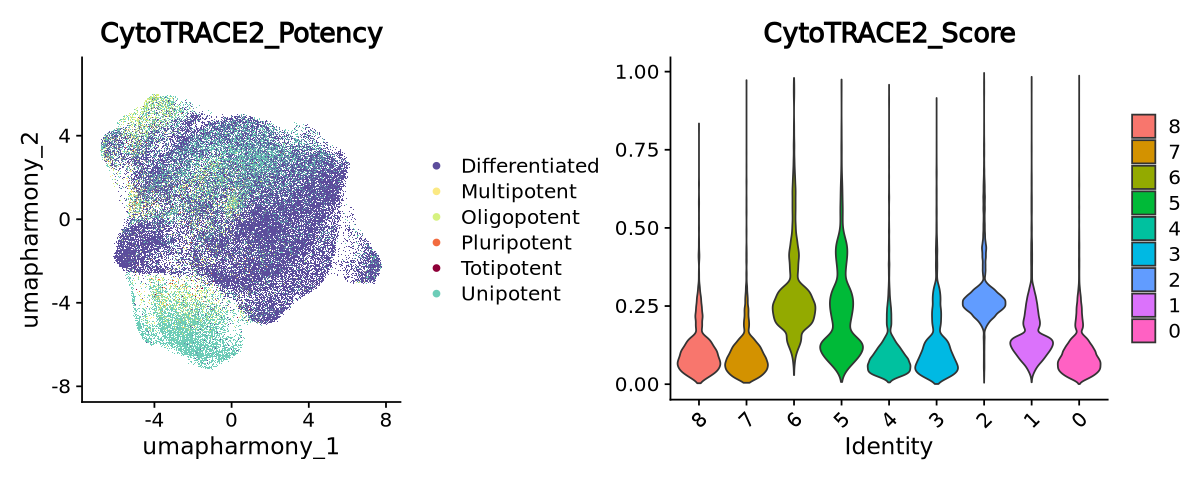

In [198]:
potency_colors <- c(
  "Totipotent" = "#8E0038",
  "Pluripotent" = "#F26B3F",
  "Multipotent" = "#FBE983",
  "Oligopotent" = "#D6F280",
  "Unipotent" = "#6DCDB8",
  "Differentiated" = "#5C4D9C"
)
options(repr.plot.width = 10, repr.plot.height =4) 
p1 <- FeaturePlot(sub, features = "CytoTRACE2_Potency", reduction = "umap.harmony") +
  scale_color_manual(values = potency_colors) +
  labs(title = "CytoTRACE2_Potency")
p2 <- VlnPlot(sub,features=c('CytoTRACE2_Score'),pt.size=0)#+labs(title = "NET")
ggarrange(p1,p2,ncol=2)

Warning message in SetQuantile(cutoff = min.cutoff[f], data = data.feature):
“NAs introduced by coercion”
Warning message in SetQuantile(cutoff = max.cutoff[f], data = data.feature):
“NAs introduced by coercion”
Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


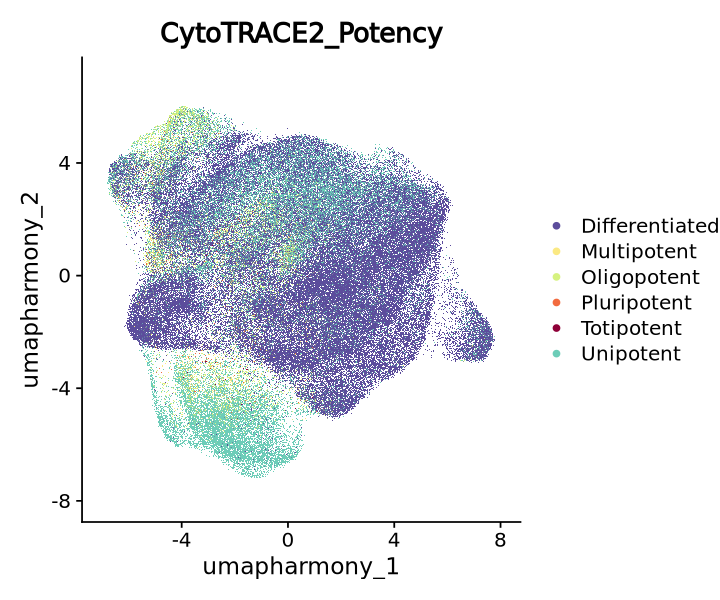

In [194]:
options(repr.plot.width = 6, repr.plot.height =5) 
sub@meta.data$CytoTRACE2_Potency <- as.character(sub@meta.data$CytoTRACE2_Potency)
FeaturePlot(sub, features = "CytoTRACE2_Potency", reduction = "umap.harmony") +
scale_color_manual(values = potency_colors) +
labs(title = "CytoTRACE2_Potency")